# Full-Day MLB Game Repricing Analysis

This is a walkthrough of the analysis for one full day of MLB games, with the goal of understanding the market dynamics of `KXMLBGAME`. This is a critical step before we scale to many games and many days, so we want to be very clear on the data shape, the analytical primitives, and the end-to-end process for one example. The date we are using is **May 20, 2026**. 
The goal here is to:

1. Explore the data shape and analytical primitives for `KXMLBGAME`, so we can be confident in our approach when we scale to many markets.
2. Demonstrate the data shape end-to-end (market metadata, orderbook snapshot, trade history) for one real example.
3. Establish the analytical primitives (price metrics, time alignment, drift definition) we'll reuse when we scale to many markets.
4. Cache the data to parquet so this notebook renders cleanly on GitHub even when the Snowflake warehouse is paused.

### Why `KXMLBGAME` and not the other markets

`KXMLBGAME` is the easiest market to do apples-to-apples comparison between games. The market is a binary "Will Team X win?". The other markets have `floor_strikes` that need to account for normalization and determination of price discovery. For example, some samples of the `KXMLBTOTAL` markets for CIN/PHI:

| market_ticker | floor_strike | YES meaning |
|-----------|-----------|-----------|
| KXMLBTOTAL-26MAY201305CINPHI-7 | 6.5 | Over 6.5 runs scored |
| KXMLBTOTAL-26MAY201305CINPHI-8 | 7.5 | Over 7.5 runs scored |
| KXMLBTOTAL-26MAY201305CINPHI-9 | 8.5 | Over 8.5 runs scored |

This means totals and spreads behave like strike ladders, where attention/liquidity may concentrate around the most relevant threshold. That makes them harder to compare directly without a moneyness or implied-line normalization step.

### Prerequisites

This notebook reads from the **dbt staging/marts** (`fct_markets`, `fct_market_orderbooks`, `stg_kalshi_market_trades`), not from `RAW`. If you've just scraped fresh data for this market, run `dbt run` first so the marts pick up the new rows:

```bash
dbt run --project-dir dbt --profiles-dir dbt
```

The first cell run will hit Snowflake once and write parquet to `analysis/data/full_day_2026-05-20`. Subsequent re-runs load from that cache and don't need a warm warehouse.

In [1]:
import json
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
from dotenv import find_dotenv, load_dotenv

from market_data_platform.warehouse import SnowflakeManager
from market_data_platform.utils.timezone import utc_to_eastern

# Walk up from the notebook's cwd to find the repo root .env
load_dotenv(find_dotenv())

MARKET_DATE = "2026-05-20"
DATA_DIR = Path("data") / f"full_day_{MARKET_DATE}"

plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


def cached_query(query: str, name: str, snowflake: SnowflakeManager | None = None) -> pd.DataFrame:
    """Load a Snowflake query result from parquet cache if present, else query and cache.

    Keeps every notebook re-executable without warehouse access as long as the cache
    is on disk — the rendered cell output in the .ipynb is what ships to GitHub.
    """
    cache_path = DATA_DIR / f"{name}.parquet"
    if cache_path.exists():
        print(f"  loaded {name} from cache ({cache_path})")
        return pd.read_parquet(cache_path)
    if snowflake is None:
        raise RuntimeError(
            f"Cache miss for {name} and no Snowflake connection provided. "
            "Pass a SnowflakeManager to populate the cache."
        )
    print(f"  cache miss for {name}; querying Snowflake...")
    rows = snowflake.execute(query)
    df = pd.DataFrame(rows)
    DATA_DIR.mkdir(parents=True, exist_ok=True)
    df.to_parquet(cache_path)
    print(f"  wrote {len(df)} rows to {cache_path}")
    return df

In [2]:
EVENT_CACHE_FILES = ("markets", "orderbooks", "trades")


def sql_literal(value: str) -> str:
    return "'" + str(value).replace("'", "''") + "'"


def event_cache_dir(event_ticker: str) -> Path:
    return DATA_DIR / event_ticker


def event_cache_path(event_ticker: str, name: str) -> Path:
    return event_cache_dir(event_ticker) / f"{name}.parquet"


def missing_event_cache_files(event_ticker: str) -> list[str]:
    return [
        name
        for name in EVENT_CACHE_FILES
        if not event_cache_path(event_ticker, name).exists()
    ]


def write_event_cache(event_ticker: str, name: str, df: pd.DataFrame) -> pd.DataFrame:
    cache_path = event_cache_path(event_ticker, name)
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    df.to_parquet(cache_path)
    print(f"  wrote {event_ticker}/{name}: {len(df)} rows -> {cache_path}")
    return df


def cached_event_query(
    event_ticker: str,
    name: str,
    query: str,
    snowflake: SnowflakeManager,
) -> pd.DataFrame:
    cache_path = event_cache_path(event_ticker, name)
    if cache_path.exists():
        print(f"  loaded {event_ticker}/{name} from cache ({cache_path})")
        return pd.read_parquet(cache_path)

    print(f"  cache miss for {event_ticker}/{name}; querying Snowflake...")
    df = pd.DataFrame(snowflake.execute(query))
    return write_event_cache(event_ticker, name, df)


# Connect only when a missing cache requires Snowflake. Per dbt/macros/
# generate_schema_name.sql, staging models materialize in PROD.STAGE and mart
# models materialize in PROD.KALSHI.
snowflake = None
events_cache_path = DATA_DIR / "events.parquet"

try:
    if events_cache_path.exists():
        events_df = pd.read_parquet(events_cache_path)
        print(f"loaded events from cache ({events_cache_path})")
    else:
        snowflake = SnowflakeManager("PROD", "STAGE")
        events_query = f"""
        with mlb_events as (
            select
                event_ticker,
                try_to_date(
                    upper(substr(split_part(event_ticker, '-', 2), 1, 7)),
                    'YYMONDD'
                ) as game_date
            from PROD.STAGE.stg_kalshi_events
            where series_ticker in ('KXMLBTOTAL', 'KXMLBSPREAD', 'KXMLBGAME')
        )
        select event_ticker
        from mlb_events
        where game_date = '{MARKET_DATE}'
        order by event_ticker
        """
        events_df = pd.DataFrame(snowflake.execute(events_query))
        DATA_DIR.mkdir(parents=True, exist_ok=True)
        events_df.to_parquet(events_cache_path)
        print(f"wrote {len(events_df)} events to {events_cache_path}")

    events = events_df["event_ticker"].dropna().drop_duplicates().tolist()
    print(f"Found {len(events)} events on {MARKET_DATE}.")

    missing_events = {
        event: missing_event_cache_files(event)
        for event in events
        if missing_event_cache_files(event)
    }

    if not missing_events:
        print(
            "All per-event cache files are present. "
            "Delete an event directory or parquet file to refresh it."
        )
    else:
        if snowflake is None:
            snowflake = SnowflakeManager("PROD", "STAGE")

        print(f"Populating cache for {len(missing_events)} event(s).")
        for event, missing_names in missing_events.items():
            print(f"\n{event}: missing {', '.join(missing_names)}")
            event_sql = sql_literal(event)

            market_df = cached_event_query(
                event,
                "markets",
                f"""
                select *
                from PROD.KALSHI.fct_markets
                where event_ticker = {event_sql}
                  and series_ticker in ('KXMLBTOTAL', 'KXMLBSPREAD', 'KXMLBGAME')
                order by market_ticker
                """,
                snowflake,
            )

            market_tickers = market_df["market_ticker"].dropna().drop_duplicates().tolist()
            print(f"  found {len(market_tickers)} markets")

            if not market_tickers:
                write_event_cache(event, "orderbooks", pd.DataFrame())
                write_event_cache(event, "trades", pd.DataFrame())
                continue

            ticker_sql = ", ".join(sql_literal(ticker) for ticker in market_tickers)

            orderbook_df = cached_event_query(
                event,
                "orderbooks",
                f"""
                select *
                from PROD.KALSHI.fct_market_orderbooks
                where market_ticker in ({ticker_sql})
                order by market_ticker
                """,
                snowflake,
            )

            trades_df = cached_event_query(
                event,
                "trades",
                f"""
                select *
                from PROD.STAGE.stg_kalshi_market_trades
                where market_ticker in ({ticker_sql})
                order by market_ticker, trade_time
                """,
                snowflake,
            )

            print(
                f"  cached {len(market_df)} markets, "
                f"{len(orderbook_df)} orderbooks, {len(trades_df)} trades"
            )
finally:
    if snowflake is not None:
        snowflake.close()

INFO:snowflake.connector.connection:Snowflake Connector for Python Version: 4.3.0, Python Version: 3.13.12, Platform: Windows-11-10.0.26200-SP0
INFO:snowflake.connector.connection:Connecting to GLOBAL Snowflake domain


wrote 45 events to data\full_day_2026-05-20\events.parquet
Found 45 events on 2026-05-20.
Populating cache for 45 event(s).

KXMLBGAME-26MAY201305CINPHI: missing markets, orderbooks, trades
  cache miss for KXMLBGAME-26MAY201305CINPHI/markets; querying Snowflake...
  wrote KXMLBGAME-26MAY201305CINPHI/markets: 2 rows -> data\full_day_2026-05-20\KXMLBGAME-26MAY201305CINPHI\markets.parquet
  found 2 markets
  cache miss for KXMLBGAME-26MAY201305CINPHI/orderbooks; querying Snowflake...
  wrote KXMLBGAME-26MAY201305CINPHI/orderbooks: 2 rows -> data\full_day_2026-05-20\KXMLBGAME-26MAY201305CINPHI\orderbooks.parquet
  cache miss for KXMLBGAME-26MAY201305CINPHI/trades; querying Snowflake...
  wrote KXMLBGAME-26MAY201305CINPHI/trades: 18184 rows -> data\full_day_2026-05-20\KXMLBGAME-26MAY201305CINPHI\trades.parquet
  cached 2 markets, 2 orderbooks, 18184 trades

KXMLBGAME-26MAY201310BALTB: missing markets, orderbooks, trades
  cache miss for KXMLBGAME-26MAY201310BALTB/markets; querying Snowflak

# Available Events on May 20, 2026

In [3]:
display_events = pd.DataFrame(events, columns=["market_ticker"])
display_events['series_ticker'] = display_events['market_ticker'].str.split('-').str[0]
display_events['date_time_teams'] = display_events['market_ticker'].str.split('-').str[1]
display_events['date'] = display_events['date_time_teams'].str[:7] # first 7 chars is date e.g. 26MAY10
display_events['start_time'] = display_events['date_time_teams'].str[7:11] # next 4 chars is start time e.g. 13:05 EST
display_events['teams'] = display_events['date_time_teams'].str[11:] # remaining chars is teams e.g. DETKC
display_events['start_time_est'] = pd.to_datetime(display_events['start_time'], format='%H%M').dt.time
del display_events['date_time_teams'], display_events['start_time']
display_events

,market_ticker,series_ticker,date,teams,start_time_est
0,KXMLBGAME-26MAY201305CINPHI,KXMLBGAME,26MAY20,CINPHI,13:05:00
1,KXMLBGAME-26MAY201310BALTB,KXMLBGAME,26MAY20,BALTB,13:10:00
2,KXMLBGAME-26MAY201340HOUMIN,KXMLBGAME,26MAY20,HOUMIN,13:40:00
3,KXMLBGAME-26MAY201510TEXCOL,KXMLBGAME,26MAY20,TEXCOL,15:10:00
4,KXMLBGAME-26MAY201540SFAZ,KXMLBGAME,26MAY20,SFAZ,15:40:00
5,KXMLBGAME-26MAY201610CWSSEA,KXMLBGAME,26MAY20,CWSSEA,16:10:00
6,KXMLBGAME-26MAY201840ATLMIA,KXMLBGAME,26MAY20,ATLMIA,18:40:00
7,KXMLBGAME-26MAY201840CLEDET,KXMLBGAME,26MAY20,CLEDET,18:40:00
8,KXMLBGAME-26MAY201845NYMWSH,KXMLBGAME,26MAY20,NYMWSH,18:45:00
9,KXMLBGAME-26MAY201905TORNYY,KXMLBGAME,26MAY20,TORNYY,19:05:00


## Reminders

The `fct_markets` row tells us what the contract resolves on, when trading opened and closed, and the latest price snapshot at scrape time. A few Kalshi field-name conventions worth keeping in mind:

- **`_dollars`** suffix — the value is denominated in dollars (e.g. `last_price_dollars = 0.42` means the last trade cleared at 42¢).
- **`_fp`** suffix — Kalshi's "fixed-point" convention; the value is an integer count of contracts with no decimal scaling. `volume_fp` is the lifetime contract count traded.
- **`yes_*` / `no_*`** — two sides of the binary market. YES pays $1 if the market resolves true, NO pays $1 if it resolves false. Prices sum to ~$1 (modulo the bid-ask spread).

Market-level stats: 30 market tickers across 45 events on 2026-05-20.


,series_ticker,event_ticker,market_ticker,total_trades,open_yes_price,close_yes_price,average_yes_price,yes_price_delta_dollars,average_trade_size,min_trade_size,max_trade_size,orderbook_yes_implied_std_dollars,peak_trade_hour_et,peak_trade_hour_trade_count
0,KXMLBGAME,KXMLBGAME-26MAY201305CINPHI,KXMLBGAME-26MAY201305CINPHI-CIN,9311,0.43,0.99,0.661760,0.56,237.522003,0.01,50000.00,NaN,2026-05-20 14:00 EDT,2758
1,KXMLBGAME,KXMLBGAME-26MAY201305CINPHI,KXMLBGAME-26MAY201305CINPHI-PHI,8695,0.57,0.01,0.364823,-0.56,196.706822,0.01,31666.00,NaN,2026-05-20 14:00 EDT,2580
2,KXMLBGAME,KXMLBGAME-26MAY201310BALTB,KXMLBGAME-26MAY201310BALTB-BAL,7123,0.48,0.01,0.534707,-0.47,262.437728,0.01,78431.00,NaN,2026-05-20 15:00 EDT,2840
3,KXMLBGAME,KXMLBGAME-26MAY201310BALTB,KXMLBGAME-26MAY201310BALTB-TB,16724,0.53,0.99,0.496240,0.46,296.561420,0.01,35898.26,NaN,2026-05-20 15:00 EDT,4960
4,KXMLBGAME,KXMLBGAME-26MAY201340HOUMIN,KXMLBGAME-26MAY201340HOUMIN-HOU,4456,0.41,0.01,0.289719,-0.40,205.326313,0.02,27756.92,NaN,2026-05-20 14:00 EDT,1837
5,KXMLBGAME,KXMLBGAME-26MAY201340HOUMIN,KXMLBGAME-26MAY201340HOUMIN-MIN,4726,0.60,0.99,0.703034,0.39,202.320491,0.02,50000.00,NaN,2026-05-20 15:00 EDT,1491
6,KXMLBGAME,KXMLBGAME-26MAY201510TEXCOL,KXMLBGAME-26MAY201510TEXCOL-COL,11731,0.46,0.01,0.463273,-0.45,176.470827,0.02,20000.00,NaN,2026-05-20 17:00 EDT,5148
7,KXMLBGAME,KXMLBGAME-26MAY201510TEXCOL,KXMLBGAME-26MAY201510TEXCOL-TEX,22041,0.54,0.99,0.520507,0.45,225.244596,0.01,35493.74,NaN,2026-05-20 17:00 EDT,9198
8,KXMLBGAME,KXMLBGAME-26MAY201540SFAZ,KXMLBGAME-26MAY201540SFAZ-AZ,8176,0.55,0.99,0.647864,0.44,242.764329,0.01,27007.72,NaN,2026-05-20 16:00 EDT,2902
9,KXMLBGAME,KXMLBGAME-26MAY201540SFAZ,KXMLBGAME-26MAY201540SFAZ-SF,6829,0.46,0.01,0.344172,-0.45,215.992492,0.01,32622.85,NaN,2026-05-20 16:00 EDT,2796



Series-level stats: 1 series rows. Price and orderbook columns are market-level means.


,series_ticker,market_count,total_trades,open_yes_price,close_yes_price,average_yes_price,yes_price_delta_dollars,average_trade_size,min_trade_size,max_trade_size,orderbook_yes_implied_std_dollars,peak_trade_hour_et,peak_trade_hour_trade_count
0,KXMLBGAME,30,273792,0.504,0.5,0.487469,-0.004,219.043776,0.01,103285.38,0.371742,2026-05-20 23:00 EDT,32203


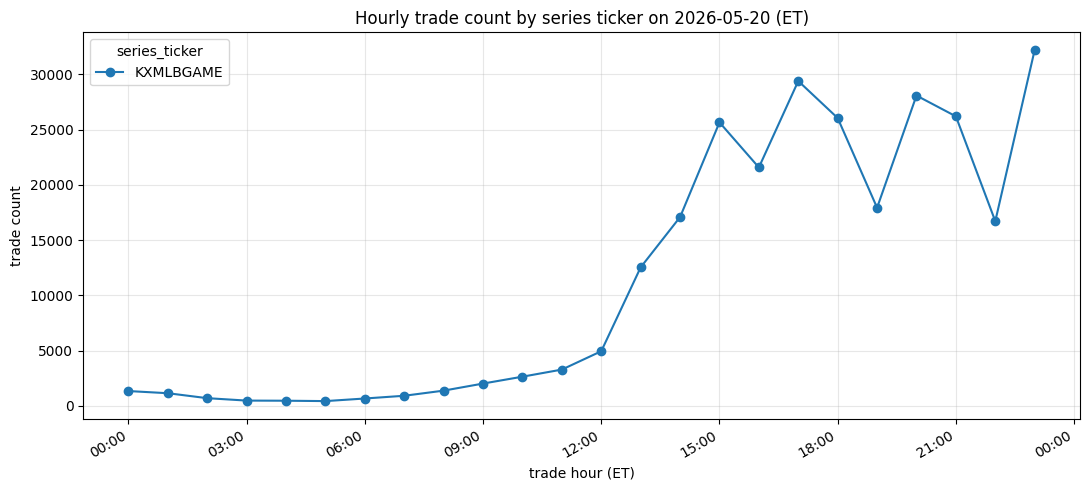

In [4]:
from IPython.display import display
from zoneinfo import ZoneInfo

import numpy as np

EASTERN = ZoneInfo('America/New_York')
analysis_date = pd.Timestamp(MARKET_DATE).date()
event_dirs = sorted(path for path in DATA_DIR.iterdir() if path.is_dir())

if not event_dirs:
    raise FileNotFoundError(f'No per-event cache directories found under {DATA_DIR}')

missing_cache_paths = [
    event_dir / f'{name}.parquet'
    for event_dir in event_dirs
    for name in EVENT_CACHE_FILES
    if not (event_dir / f'{name}.parquet').exists()
]
if missing_cache_paths:
    missing = ', '.join(str(path) for path in missing_cache_paths[:10])
    raise FileNotFoundError(f'Missing per-event cache files: {missing}')


def read_event_cache(name: str) -> pd.DataFrame:
    frames = []
    for event_dir in event_dirs:
        df = pd.read_parquet(event_dir / f'{name}.parquet').copy()
        df['cache_event_ticker'] = event_dir.name
        frames.append(df)
    return pd.concat(frames, ignore_index=True)


def coerce_numeric(df: pd.DataFrame, columns: tuple[str, ...]) -> pd.DataFrame:
    for column in columns:
        if column in df.columns:
            df[column] = pd.to_numeric(df[column], errors='coerce')
    return df


def weighted_std(values: list[float], weights: list[float]) -> float:
    value_array = np.asarray(values, dtype='float64')
    weight_array = np.asarray(weights, dtype='float64')
    if len(value_array) == 0:
        return np.nan
    if len(value_array) == 1:
        return 0.0
    if not np.isfinite(weight_array).all() or weight_array.sum() <= 0:
        return float(np.nanstd(value_array))
    average = np.average(value_array, weights=weight_array)
    variance = np.average((value_array - average) ** 2, weights=weight_array)
    return float(np.sqrt(variance))


def orderbook_yes_implied_std(orderbook_value) -> float:
    if orderbook_value is None:
        return np.nan
    if isinstance(orderbook_value, str):
        orderbook = json.loads(orderbook_value)
    elif isinstance(orderbook_value, dict):
        orderbook = orderbook_value
    else:
        return np.nan

    prices = []
    sizes = []
    for side in ('yes_dollars', 'no_dollars'):
        for level in orderbook.get(side, []) or []:
            if not level:
                continue
            price = float(level[0])
            size = float(level[1]) if len(level) > 1 else 1.0
            prices.append(1.0 - price if side == 'no_dollars' else price)
            sizes.append(size)
    return weighted_std(prices, sizes)


all_markets_df = read_event_cache('markets')
all_orderbooks_df = read_event_cache('orderbooks')
all_trades_df = read_event_cache('trades')

SERIES_TICKER = 'KXMLBGAME'

all_markets_df = all_markets_df.loc[
    all_markets_df['series_ticker'].eq(SERIES_TICKER)
].copy()
game_market_tickers = all_markets_df['market_ticker'].dropna().unique()
all_orderbooks_df = all_orderbooks_df.loc[
    all_orderbooks_df['market_ticker'].isin(game_market_tickers)
].copy()
all_trades_df = all_trades_df.loc[
    all_trades_df['market_ticker'].isin(game_market_tickers)
].copy()

all_markets_df = coerce_numeric(
    all_markets_df,
    ('last_price_dollars', 'volume_fp', 'liquidity_dollars'),
)
all_trades_df = coerce_numeric(
    all_trades_df,
    ('count_fp', 'yes_price_dollars', 'no_price_dollars'),
)

market_universe = all_markets_df.drop_duplicates('market_ticker').copy()
market_universe = market_universe[
    ['series_ticker', 'event_ticker', 'market_ticker', 'market_title', 'market_status']
]

all_trades_df['trade_time_et'] = utc_to_eastern(pd.to_datetime(all_trades_df['trade_time']))
day_trades_df = all_trades_df.loc[
    all_trades_df['trade_time_et'].dt.date == analysis_date
].copy()
day_trades_df['trade_hour_et'] = day_trades_df['trade_time_et'].dt.floor('h')

sorted_day_trades = day_trades_df.sort_values(['market_ticker', 'trade_time_et'])
trade_stats = sorted_day_trades.groupby('market_ticker', as_index=False).agg(
    total_trades=('trade_id', 'size'),
    open_yes_price=('yes_price_dollars', 'first'),
    close_yes_price=('yes_price_dollars', 'last'),
    average_yes_price=('yes_price_dollars', 'mean'),
    average_trade_size=('count_fp', 'mean'),
    min_trade_size=('count_fp', 'min'),
    max_trade_size=('count_fp', 'max'),
)

market_hourly = day_trades_df.groupby(
    ['market_ticker', 'trade_hour_et'],
    as_index=False,
).size().rename(columns={'size': 'peak_trade_hour_trade_count'})
market_peak = market_hourly.loc[
    market_hourly.groupby('market_ticker')['peak_trade_hour_trade_count'].idxmax()
].copy()
market_peak['peak_trade_hour_et'] = market_peak['trade_hour_et'].dt.strftime('%Y-%m-%d %H:%M %Z')
market_peak = market_peak[
    ['market_ticker', 'peak_trade_hour_et', 'peak_trade_hour_trade_count']
]

orderbook_stats = all_orderbooks_df.drop_duplicates('market_ticker').copy()
orderbook_stats['orderbook_yes_implied_std_dollars'] = orderbook_stats['orderbook'].apply(
    orderbook_yes_implied_std
)
orderbook_stats = orderbook_stats[
    ['market_ticker', 'orderbook_yes_implied_std_dollars']
]

market_stats = (
    market_universe
    .merge(trade_stats, on='market_ticker', how='left')
    .merge(orderbook_stats, on='market_ticker', how='left')
    .merge(market_peak, on='market_ticker', how='left')
)
market_stats['total_trades'] = market_stats['total_trades'].fillna(0).astype(int)
market_stats['yes_price_delta_dollars'] = (
    market_stats['close_yes_price'] - market_stats['open_yes_price']
)

market_stat_columns = [
    'series_ticker',
    'event_ticker',
    'market_ticker',
    'total_trades',
    'open_yes_price',
    'close_yes_price',
    'average_yes_price',
    'yes_price_delta_dollars',
    'average_trade_size',
    'min_trade_size',
    'max_trade_size',
    'orderbook_yes_implied_std_dollars',
    'peak_trade_hour_et',
    'peak_trade_hour_trade_count',
]
market_stats_display = market_stats[market_stat_columns].sort_values(
    ['series_ticker', 'event_ticker', 'market_ticker']
).reset_index(drop=True)

print(
    f'Market-level stats: {len(market_stats_display)} market tickers '
    f'across {len(event_dirs)} events on {MARKET_DATE}.'
)
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(market_stats_display)

market_series = market_universe[['market_ticker', 'series_ticker']]
day_trades_with_series = day_trades_df.merge(market_series, on='market_ticker', how='left')

series_trade_stats = day_trades_with_series.groupby('series_ticker', as_index=False).agg(
    total_trades=('trade_id', 'size'),
    average_yes_price=('yes_price_dollars', 'mean'),
    average_trade_size=('count_fp', 'mean'),
    min_trade_size=('count_fp', 'min'),
    max_trade_size=('count_fp', 'max'),
)
series_market_stats = market_stats.groupby('series_ticker', as_index=False).agg(
    market_count=('market_ticker', 'nunique'),
    open_yes_price=('open_yes_price', 'mean'),
    close_yes_price=('close_yes_price', 'mean'),
    yes_price_delta_dollars=('yes_price_delta_dollars', 'mean'),
    orderbook_yes_implied_std_dollars=('orderbook_yes_implied_std_dollars', 'mean'),
)

series_hourly = day_trades_with_series.groupby(
    ['series_ticker', 'trade_hour_et'],
    as_index=False,
).size().rename(columns={'size': 'trade_count'})
series_peak = series_hourly.loc[
    series_hourly.groupby('series_ticker')['trade_count'].idxmax()
].copy()
series_peak['peak_trade_hour_et'] = series_peak['trade_hour_et'].dt.strftime('%Y-%m-%d %H:%M %Z')
series_peak = series_peak.rename(columns={'trade_count': 'peak_trade_hour_trade_count'})[
    ['series_ticker', 'peak_trade_hour_et', 'peak_trade_hour_trade_count']
]

series_stats = (
    series_market_stats
    .merge(series_trade_stats, on='series_ticker', how='left')
    .merge(series_peak, on='series_ticker', how='left')
)
series_stats['total_trades'] = series_stats['total_trades'].fillna(0).astype(int)
series_stats_display = series_stats[
    ['series_ticker', 'market_count'] + market_stat_columns[3:]
].sort_values('series_ticker').reset_index(drop=True)

print()
print(
    f'Series-level stats: {len(series_stats_display)} series rows. '
    'Price and orderbook columns are market-level means.'
)
display(series_stats_display)

if not series_hourly.empty:
    series_hourly_pivot = series_hourly.pivot(
        index='trade_hour_et',
        columns='series_ticker',
        values='trade_count',
    ).fillna(0).sort_index()

    fig, ax = plt.subplots(figsize=(11, 5))
    for series_ticker in series_hourly_pivot.columns:
        ax.plot(
            series_hourly_pivot.index,
            series_hourly_pivot[series_ticker],
            marker='o',
            label=series_ticker,
        )

    ax.set_title(f'Hourly trade count by series ticker on {MARKET_DATE} (ET)')
    ax.set_xlabel('trade hour (ET)')
    ax.set_ylabel('trade count')
    ax.legend(title='series_ticker')
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=3, tz=EASTERN))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M', tz=EASTERN))
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()


## Pregame

Using `KXMLBGAME`, we are looking to asssess the quality of the pregame market as a predictor of the eventual winner, and understand the dynamics of how the market evolves from open to first pitch. 

## Questions we are looking to answer
* Does the pregame market move toward the eventual winner before first pitch?
* Does forecast quality improve from first observed trade/open to first pitch?
* Is the improvement gradual, or concentrated near first pitch?
* Does liquidity, trade count, volume, or available order book depth correlate with smoother or more accurate pregame price discovery?

## Primary Metric

To assess the "accuracy of the pregame market, I will be using **Brier** score. A Brier score measures the accuracy of probabilistic predictions, primarily for binary or categorical outcomes (e.g., "win or no win"). It calculates the mean squared difference between the predicted probabilities and the actual outcomes, resulting in a number between \(0\) and \(1\).

```
Brier score = (predicted_probability - actual_outcome)^2
```

Lower is better. For the eventual winner, a price moving from 0.55 to 0.65 before first pitch improves the Brier score; moving from 0.55 to 0.45 worsens it. It punishes confident wrong predictions more than uncertain wrong predictions - the closer the prediction is to 1, and is wrong, the more of a penalty there is to the prediction.

In [5]:
# Build a KXMLBGAME-only pregame panel with outcome labels.
# Kalshi settlement fields in this cache are still blank, so this fixed-date
# notebook falls back to official MLB winners for the May 20, 2026 slate.
import re

KXMLBGAME_WINNER_BY_EVENT = {
    'KXMLBGAME-26MAY201305CINPHI': 'CIN',
    'KXMLBGAME-26MAY201310BALTB': 'TB',
    'KXMLBGAME-26MAY201340HOUMIN': 'MIN',
    'KXMLBGAME-26MAY201510TEXCOL': 'TEX',
    'KXMLBGAME-26MAY201540SFAZ': 'AZ',
    'KXMLBGAME-26MAY201610CWSSEA': 'SEA',
    'KXMLBGAME-26MAY201840ATLMIA': 'ATL',
    'KXMLBGAME-26MAY201840CLEDET': 'CLE',
    'KXMLBGAME-26MAY201845NYMWSH': 'WSH',
    'KXMLBGAME-26MAY201905TORNYY': 'TOR',
    'KXMLBGAME-26MAY201940BOSKC': 'BOS',
    'KXMLBGAME-26MAY201940MILCHC': 'MIL',
    'KXMLBGAME-26MAY201945PITSTL': 'PIT',
    'KXMLBGAME-26MAY202040LADSD': 'LAD',
    'KXMLBGAME-26MAY202138ATHLAA': 'ATH',
}


def parse_game_start_et(event_ticker: str) -> pd.Timestamp:
    event_key = str(event_ticker).split('-', 1)[1]
    game_start = pd.to_datetime(event_key[:11], format='%y%b%d%H%M')
    return game_start.tz_localize(EASTERN)


def normalize_result(value) -> str | None:
    if value is None or pd.isna(value):
        return None
    result = str(value).strip().lower()
    if result in {'yes', 'no'}:
        return result
    return None


def outcome_from_market_row(row: pd.Series) -> tuple[float, str]:
    market_result = normalize_result(row.get('market_result'))
    if market_result == 'yes':
        return 1.0, 'kalshi_market_result'
    if market_result == 'no':
        return 0.0, 'kalshi_market_result'

    winner_team_code = KXMLBGAME_WINNER_BY_EVENT.get(row['event_ticker'])
    if winner_team_code is None:
        return np.nan, 'missing'
    return float(row['team_code'] == winner_team_code), 'manual_mlb_result_map'


kxmlbgame_markets = all_markets_df.loc[
    all_markets_df['series_ticker'].eq('KXMLBGAME')
].drop_duplicates('market_ticker').copy()

kxmlbgame_markets = coerce_numeric(
    kxmlbgame_markets,
    (
        'last_price_dollars',
        'liquidity_dollars',
        'volume_fp',
        'yes_bid_size_fp',
        'yes_ask_size_fp',
        'yes_bid_dollars',
        'yes_ask_dollars',
    ),
)
kxmlbgame_markets['team_code'] = kxmlbgame_markets['market_ticker'].str.rsplit('-', n=1).str[-1]
kxmlbgame_markets['winner_team_code'] = kxmlbgame_markets['event_ticker'].map(KXMLBGAME_WINNER_BY_EVENT)
kxmlbgame_markets['game_start_et'] = kxmlbgame_markets['event_ticker'].apply(parse_game_start_et)

outcome_pairs = kxmlbgame_markets.apply(outcome_from_market_row, axis=1, result_type='expand')
kxmlbgame_markets['actual_outcome'] = outcome_pairs[0]
kxmlbgame_markets['outcome_source'] = outcome_pairs[1]

kxmlbgame_trades = all_trades_df.merge(
    kxmlbgame_markets[
        [
            'event_ticker',
            'market_ticker',
            'team_code',
            'winner_team_code',
            'game_start_et',
            'actual_outcome',
        ]
    ],
    on='market_ticker',
    how='inner',
    suffixes=('', '_market'),
)
kxmlbgame_trades = kxmlbgame_trades.dropna(subset=['trade_time_et', 'yes_price_dollars', 'actual_outcome']).copy()
kxmlbgame_trades['window'] = np.where(
    kxmlbgame_trades['trade_time_et'] < kxmlbgame_trades['game_start_et'],
    'pregame',
    'live',
)

pregame_trades = kxmlbgame_trades.loc[
    kxmlbgame_trades['window'].eq('pregame')
].sort_values(['market_ticker', 'trade_time_et']).copy()
pregame_trades['winner_probability'] = np.where(
    pregame_trades['actual_outcome'].eq(1.0),
    pregame_trades['yes_price_dollars'],
    1.0 - pregame_trades['yes_price_dollars'],
)
pregame_trades['brier_score'] = (
    pregame_trades['yes_price_dollars'] - pregame_trades['actual_outcome']
) ** 2

print(
    f'KXMLBGAME pregame trades: {len(pregame_trades):,} trades across '
    f'{pregame_trades["market_ticker"].nunique()} markets and '
    f'{pregame_trades["event_ticker"].nunique()} games.'
)
print('Outcome sources:')
display(kxmlbgame_markets['outcome_source'].value_counts(dropna=False).rename_axis('source').reset_index(name='markets'))


KXMLBGAME pregame trades: 47,066 trades across 30 markets and 15 games.
Outcome sources:


,source,markets
0,kalshi_market_result,30


In [6]:
# Answer 1 and 2: did pregame prices move toward the eventual winner,
# and did Brier forecast quality improve from first observed trade to first pitch?
def summarize_pregame_market(group: pd.DataFrame) -> pd.Series:
    group = group.sort_values('trade_time_et').copy()
    first = group.iloc[0]
    last = group.iloc[-1]
    winner_prob_path = group['winner_probability']
    total_abs_winner_prob_move = winner_prob_path.diff().abs().sum()
    net_winner_prob_change = last['winner_probability'] - first['winner_probability']
    elapsed_hours = (last['trade_time_et'] - first['trade_time_et']).total_seconds() / 3600

    if group['trade_time_et'].nunique() > 1:
        hours_from_first = (
            group['trade_time_et'] - group['trade_time_et'].min()
        ).dt.total_seconds() / 3600
        winner_prob_slope_per_hour = np.polyfit(hours_from_first, winner_prob_path, 1)[0]
    else:
        winner_prob_slope_per_hour = np.nan

    return pd.Series(
        {
            'event_ticker': first['event_ticker'],
            'team_code': first['team_code'],
            'winner_team_code': first['winner_team_code'],
            'actual_outcome': first['actual_outcome'],
            'first_trade_et': first['trade_time_et'],
            'last_pregame_trade_et': last['trade_time_et'],
            'game_start_et': first['game_start_et'],
            'hours_observed_pregame': elapsed_hours,
            'pregame_trade_count': len(group),
            'pregame_volume': group['count_fp'].sum(),
            'open_yes_price': first['yes_price_dollars'],
            'first_pitch_yes_price': last['yes_price_dollars'],
            'yes_price_change': last['yes_price_dollars'] - first['yes_price_dollars'],
            'winner_prob_open': first['winner_probability'],
            'winner_prob_first_pitch': last['winner_probability'],
            'winner_prob_change': net_winner_prob_change,
            'moved_toward_winner': net_winner_prob_change > 0,
            'brier_open': first['brier_score'],
            'brier_first_pitch': last['brier_score'],
            'brier_improvement': first['brier_score'] - last['brier_score'],
            'forecast_improved': first['brier_score'] > last['brier_score'],
            'total_abs_winner_prob_move': total_abs_winner_prob_move,
            'path_efficiency': (
                abs(net_winner_prob_change) / total_abs_winner_prob_move
                if total_abs_winner_prob_move > 0
                else np.nan
            ),
            'winner_prob_slope_per_hour': winner_prob_slope_per_hour,
        }
    )


pregame_market_summary = pd.DataFrame(
    [
        summarize_pregame_market(group).rename(market_ticker)
        for market_ticker, group in pregame_trades.groupby('market_ticker')
    ]
).rename_axis('market_ticker').reset_index()

market_context_cols = [
    'market_ticker',
    'market_title',
    'market_status',
    'last_price_dollars',
    'volume_fp',
    'liquidity_dollars',
    'yes_bid_dollars',
    'yes_ask_dollars',
    'yes_bid_size_fp',
    'yes_ask_size_fp',
    'outcome_source',
]
pregame_market_summary = pregame_market_summary.merge(
    kxmlbgame_markets[[c for c in market_context_cols if c in kxmlbgame_markets.columns]],
    on='market_ticker',
    how='left',
)

pregame_event_summary = pregame_market_summary.groupby('event_ticker', as_index=False).agg(
    winner_team_code=('winner_team_code', 'first'),
    markets=('market_ticker', 'nunique'),
    pregame_trade_count=('pregame_trade_count', 'sum'),
    pregame_volume=('pregame_volume', 'sum'),
    mean_winner_prob_open=('winner_prob_open', 'mean'),
    mean_winner_prob_first_pitch=('winner_prob_first_pitch', 'mean'),
    mean_winner_prob_change=('winner_prob_change', 'mean'),
    mean_brier_open=('brier_open', 'mean'),
    mean_brier_first_pitch=('brier_first_pitch', 'mean'),
    mean_brier_improvement=('brier_improvement', 'mean'),
    mean_path_efficiency=('path_efficiency', 'mean'),
)
pregame_event_summary['forecast_improved'] = pregame_event_summary['mean_brier_improvement'] > 0
pregame_event_summary['moved_toward_winner'] = pregame_event_summary['mean_winner_prob_change'] > 0

answer_summary = pd.DataFrame(
    [
        {
            'question': 'Markets moved toward eventual winner',
            'yes_count': int(pregame_market_summary['moved_toward_winner'].sum()),
            'total': len(pregame_market_summary),
            'share': pregame_market_summary['moved_toward_winner'].mean(),
        },
        {
            'question': 'Markets improved Brier score',
            'yes_count': int(pregame_market_summary['forecast_improved'].sum()),
            'total': len(pregame_market_summary),
            'share': pregame_market_summary['forecast_improved'].mean(),
        },
        {
            'question': 'Games moved toward eventual winner',
            'yes_count': int(pregame_event_summary['moved_toward_winner'].sum()),
            'total': len(pregame_event_summary),
            'share': pregame_event_summary['moved_toward_winner'].mean(),
        },
        {
            'question': 'Games improved mean Brier score',
            'yes_count': int(pregame_event_summary['forecast_improved'].sum()),
            'total': len(pregame_event_summary),
            'share': pregame_event_summary['forecast_improved'].mean(),
        },
    ]
)

print('Pregame directional and Brier answers')
display(answer_summary)

market_display_cols = [
    'event_ticker',
    'market_ticker',
    'team_code',
    'winner_team_code',
    'pregame_trade_count',
    'open_yes_price',
    'first_pitch_yes_price',
    'winner_prob_open',
    'winner_prob_first_pitch',
    'winner_prob_change',
    'brier_open',
    'brier_first_pitch',
    'brier_improvement',
    'path_efficiency',
]
print('Market-level pregame summary')
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(
        pregame_market_summary[market_display_cols]
        .sort_values(['event_ticker', 'team_code'])
        .reset_index(drop=True)
    )

print('Game-level pregame summary (averaging the two complementary team contracts)')
display(
    pregame_event_summary.sort_values('mean_brier_improvement', ascending=False).reset_index(drop=True)
)


Pregame directional and Brier answers


,question,yes_count,total,share
0,Markets moved toward eventual winner,15,30,0.500000
1,Markets improved Brier score,15,30,0.500000
2,Games moved toward eventual winner,5,15,0.333333
3,Games improved mean Brier score,6,15,0.400000


Market-level pregame summary


,event_ticker,market_ticker,team_code,winner_team_code,pregame_trade_count,open_yes_price,first_pitch_yes_price,winner_prob_open,winner_prob_first_pitch,winner_prob_change,brier_open,brier_first_pitch,brier_improvement,path_efficiency
0,KXMLBGAME-26MAY201305CINPHI,KXMLBGAME-26MAY201305CINPHI-CIN,CIN,CIN,1748,0.38,0.42,0.38,0.42,0.04,0.3844,0.3364,0.0480,0.037736
1,KXMLBGAME-26MAY201305CINPHI,KXMLBGAME-26MAY201305CINPHI-PHI,PHI,CIN,1916,0.62,0.59,0.38,0.41,0.03,0.3844,0.3481,0.0363,0.020134
2,KXMLBGAME-26MAY201310BALTB,KXMLBGAME-26MAY201310BALTB-BAL,BAL,TB,990,0.46,0.49,0.54,0.51,-0.03,0.2116,0.2401,-0.0285,0.026087
3,KXMLBGAME-26MAY201310BALTB,KXMLBGAME-26MAY201310BALTB-TB,TB,TB,5262,0.52,0.53,0.52,0.53,0.01,0.2304,0.2209,0.0095,0.004878
4,KXMLBGAME-26MAY201340HOUMIN,KXMLBGAME-26MAY201340HOUMIN-HOU,HOU,MIN,820,0.40,0.44,0.60,0.56,-0.04,0.1600,0.1936,-0.0336,0.105263
5,KXMLBGAME-26MAY201340HOUMIN,KXMLBGAME-26MAY201340HOUMIN-MIN,MIN,MIN,1537,0.61,0.57,0.61,0.57,-0.04,0.1521,0.1849,-0.0328,0.066667
6,KXMLBGAME-26MAY201510TEXCOL,KXMLBGAME-26MAY201510TEXCOL-COL,COL,TEX,455,0.48,0.47,0.52,0.53,0.01,0.2304,0.2209,0.0095,0.014493
7,KXMLBGAME-26MAY201510TEXCOL,KXMLBGAME-26MAY201510TEXCOL-TEX,TEX,TEX,1975,0.55,0.54,0.55,0.54,-0.01,0.2025,0.2116,-0.0091,0.009901
8,KXMLBGAME-26MAY201540SFAZ,KXMLBGAME-26MAY201540SFAZ-AZ,AZ,AZ,1264,0.54,0.51,0.54,0.51,-0.03,0.2116,0.2401,-0.0285,0.049180
9,KXMLBGAME-26MAY201540SFAZ,KXMLBGAME-26MAY201540SFAZ-SF,SF,AZ,820,0.48,0.50,0.52,0.50,-0.02,0.2304,0.2500,-0.0196,0.023256


Game-level pregame summary (averaging the two complementary team contracts)


,event_ticker,winner_team_code,markets,pregame_trade_count,pregame_volume,mean_winner_prob_open,mean_winner_prob_first_pitch,mean_winner_prob_change,mean_brier_open,mean_brier_first_pitch,mean_brier_improvement,mean_path_efficiency,forecast_improved,moved_toward_winner
0,KXMLBGAME-26MAY202040LADSD,LAD,2,4968,567310.05,0.575,0.635,0.060,0.18065,0.13325,0.04740,0.029472,True,True
1,KXMLBGAME-26MAY201840CLEDET,CLE,2,2295,393850.57,0.480,0.525,0.045,0.27040,0.22565,0.04475,0.023679,True,True
2,KXMLBGAME-26MAY201305CINPHI,CIN,2,3664,746237.58,0.380,0.415,0.035,0.38440,0.34225,0.04215,0.028935,True,True
3,KXMLBGAME-26MAY202138ATHLAA,ATH,2,3675,952090.78,0.525,0.545,0.020,0.22565,0.20705,0.01860,0.008295,True,True
4,KXMLBGAME-26MAY201945PITSTL,PIT,2,2116,310131.23,0.470,0.485,0.015,0.28090,0.26525,0.01565,0.027661,True,True
5,KXMLBGAME-26MAY201510TEXCOL,TEX,2,2430,493021.56,0.535,0.535,0.000,0.21645,0.21625,0.00020,0.012197,True,False
6,KXMLBGAME-26MAY201905TORNYY,TOR,2,2653,318815.25,0.385,0.385,0.000,0.37825,0.37825,0.00000,0.013460,False,False
7,KXMLBGAME-26MAY201940MILCHC,MIL,2,3774,776065.94,0.500,0.490,-0.010,0.26000,0.26020,-0.00020,0.082763,False,False
8,KXMLBGAME-26MAY201610CWSSEA,SEA,2,2346,360612.51,0.575,0.565,-0.010,0.18065,0.18925,-0.00860,0.018331,False,False
9,KXMLBGAME-26MAY201310BALTB,TB,2,6252,2406806.32,0.530,0.520,-0.010,0.22100,0.23050,-0.00950,0.015483,False,False


In [7]:
# Reconcile contract-level and game-level Brier improvement counts.
# There are two complementary KXMLBGAME contracts per event. If the pair moved
# synchronously and summed to exactly 1.00 at the same timestamps, we would only
# expect 0 or 2 improving contracts per game. The 1-improving-contract cases are
# a useful diagnostic: they show timing, spread, or execution deltas between the
# paired markets, not necessarily a separate game-level forecast signal.
pregame_contract_pair_summary = pregame_market_summary.groupby('event_ticker', as_index=False).agg(
    winner_team_code=('winner_team_code', 'first'),
    improving_contracts=('forecast_improved', 'sum'),
    contracts=('market_ticker', 'nunique'),
    mean_brier_improvement=('brier_improvement', 'mean'),
    min_brier_improvement=('brier_improvement', 'min'),
    max_brier_improvement=('brier_improvement', 'max'),
    mean_winner_prob_change=('winner_prob_change', 'mean'),
)
pregame_contract_pair_summary['game_improved_mean_brier'] = (
    pregame_contract_pair_summary['mean_brier_improvement'] > 0
)

print(
    'Brier improvement = brier_open - brier_first_pitch. '
    'Positive means forecast error fell before first pitch; negative means it rose.'
)
print(
    'Interpret the 0/1/2 table as a paired-market synchronization check. '
    'A game with exactly 1 improving contract means the two complementary team markets '
    'did not move perfectly together over the observed pregame trade prints.'
)
print('Improving contracts per game:')
display(
    pregame_contract_pair_summary['improving_contracts']
    .value_counts()
    .sort_index()
    .rename_axis('improving_contracts')
    .reset_index(name='games')
)

display(
    pregame_contract_pair_summary
    .sort_values(['improving_contracts', 'mean_brier_improvement'], ascending=[False, False])
    .reset_index(drop=True)
)


Brier improvement = brier_open - brier_first_pitch. Positive means forecast error fell before first pitch; negative means it rose.
Interpret the 0/1/2 table as a paired-market synchronization check. A game with exactly 1 improving contract means the two complementary team markets did not move perfectly together over the observed pregame trade prints.
Improving contracts per game:


,improving_contracts,games
0,0,5
1,1,5
2,2,5


,event_ticker,winner_team_code,improving_contracts,contracts,mean_brier_improvement,min_brier_improvement,max_brier_improvement,mean_winner_prob_change,game_improved_mean_brier
0,KXMLBGAME-26MAY202040LADSD,LAD,2,2,0.04740,0.0395,0.0553,0.060,True
1,KXMLBGAME-26MAY201840CLEDET,CLE,2,2,0.04475,0.0400,0.0495,0.045,True
2,KXMLBGAME-26MAY201305CINPHI,CIN,2,2,0.04215,0.0363,0.0480,0.035,True
3,KXMLBGAME-26MAY202138ATHLAA,ATH,2,2,0.01860,0.0093,0.0279,0.020,True
4,KXMLBGAME-26MAY201945PITSTL,PIT,2,2,0.01565,0.0105,0.0208,0.015,True
5,KXMLBGAME-26MAY201510TEXCOL,TEX,1,2,0.00020,-0.0091,0.0095,0.000,True
6,KXMLBGAME-26MAY201905TORNYY,TOR,1,2,0.00000,-0.0123,0.0123,0.000,False
7,KXMLBGAME-26MAY201940MILCHC,MIL,1,2,-0.00020,-0.1104,0.1100,-0.010,False
8,KXMLBGAME-26MAY201310BALTB,TB,1,2,-0.00950,-0.0285,0.0095,-0.010,False
9,KXMLBGAME-26MAY201940BOSKC,BOS,1,2,-0.02010,-0.0505,0.0103,-0.020,False


Pregame Brier path by checkpoint


,checkpoint_order,checkpoint,markets,mean_winner_probability,median_winner_probability,mean_brier_score,median_brier_score
0,0,first_observed,30,0.515000,0.520,0.241023,0.23040
1,1,6h_before,30,0.524333,0.535,0.231323,0.21625
2,2,3h_before,30,0.520667,0.530,0.234513,0.22090
3,3,1h_before,30,0.518000,0.520,0.236927,0.23040
4,4,15m_before,30,0.516667,0.520,0.238007,0.23040
5,5,first_pitch,30,0.516000,0.515,0.238640,0.23525


Among markets with positive pregame Brier improvement, median share of that improvement occurring in the final hour: 0.00%
Median market path efficiency: 2.38%


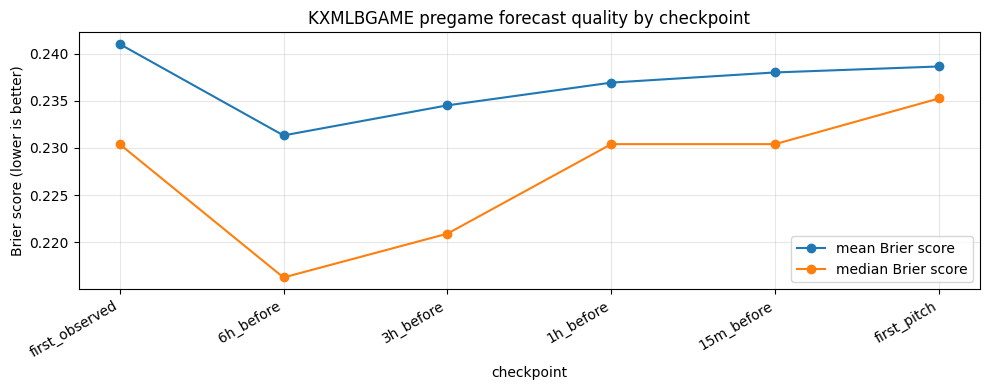

Final-hour concentration detail


,event_ticker,market_ticker,team_code,winner_team_code,total_brier_improvement,final_hour_brier_improvement,final_hour_share_of_positive_improvement,total_winner_prob_change,final_hour_winner_prob_change
0,KXMLBGAME-26MAY201940MILCHC,KXMLBGAME-26MAY201940MILCHC-MIL,MIL,MIL,0.1100,0.0101,0.091818,0.10,0.01
1,KXMLBGAME-26MAY202040LADSD,KXMLBGAME-26MAY202040LADSD-LAD,LAD,LAD,0.0553,-0.0071,-0.128391,0.07,-0.01
2,KXMLBGAME-26MAY201840CLEDET,KXMLBGAME-26MAY201840CLEDET-CLE,CLE,CLE,0.0495,0.0000,0.000000,0.05,0.00
3,KXMLBGAME-26MAY201305CINPHI,KXMLBGAME-26MAY201305CINPHI-CIN,CIN,CIN,0.0480,-0.0115,-0.239583,0.04,-0.01
4,KXMLBGAME-26MAY201840CLEDET,KXMLBGAME-26MAY201840CLEDET-DET,DET,CLE,0.0400,0.0000,0.000000,0.04,0.00
5,KXMLBGAME-26MAY202040LADSD,KXMLBGAME-26MAY202040LADSD-SD,SD,LAD,0.0395,0.0000,0.000000,0.05,0.00
6,KXMLBGAME-26MAY201305CINPHI,KXMLBGAME-26MAY201305CINPHI-PHI,PHI,CIN,0.0363,-0.0117,-0.322314,0.03,-0.01
7,KXMLBGAME-26MAY202138ATHLAA,KXMLBGAME-26MAY202138ATHLAA-ATH,ATH,ATH,0.0279,0.0000,0.000000,0.03,0.00
8,KXMLBGAME-26MAY201945PITSTL,KXMLBGAME-26MAY201945PITSTL-PIT,PIT,PIT,0.0208,0.0000,0.000000,0.02,0.00
9,KXMLBGAME-26MAY201905TORNYY,KXMLBGAME-26MAY201905TORNYY-TOR,TOR,TOR,0.0123,0.0000,0.000000,0.01,0.00


In [8]:
# Answer 3: is improvement gradual, or concentrated near first pitch?
CHECKPOINTS = [
    ('first_observed', None),
    ('6h_before', pd.Timedelta(hours=6)),
    ('3h_before', pd.Timedelta(hours=3)),
    ('1h_before', pd.Timedelta(hours=1)),
    ('15m_before', pd.Timedelta(minutes=15)),
    ('first_pitch', pd.Timedelta(0)),
]

checkpoint_rows = []
for market_ticker, group in pregame_trades.groupby('market_ticker'):
    group = group.sort_values('trade_time_et')
    first = group.iloc[0]
    for checkpoint_order, (checkpoint, offset) in enumerate(CHECKPOINTS):
        if offset is None:
            selected = first
            checkpoint_time = first['trade_time_et']
        else:
            checkpoint_time = first['game_start_et'] - offset
            eligible = group.loc[group['trade_time_et'] <= checkpoint_time]
            if eligible.empty:
                continue
            selected = eligible.iloc[-1]

        checkpoint_rows.append(
            {
                'event_ticker': first['event_ticker'],
                'market_ticker': market_ticker,
                'team_code': first['team_code'],
                'winner_team_code': first['winner_team_code'],
                'actual_outcome': first['actual_outcome'],
                'checkpoint': checkpoint,
                'checkpoint_order': checkpoint_order,
                'checkpoint_time_et': checkpoint_time,
                'observed_trade_time_et': selected['trade_time_et'],
                'yes_price': selected['yes_price_dollars'],
                'winner_probability': selected['winner_probability'],
                'brier_score': selected['brier_score'],
            }
        )

pregame_checkpoint_prices = pd.DataFrame(checkpoint_rows)
checkpoint_summary = pregame_checkpoint_prices.groupby(
    ['checkpoint_order', 'checkpoint'],
    as_index=False,
).agg(
    markets=('market_ticker', 'nunique'),
    mean_winner_probability=('winner_probability', 'mean'),
    median_winner_probability=('winner_probability', 'median'),
    mean_brier_score=('brier_score', 'mean'),
    median_brier_score=('brier_score', 'median'),
)

checkpoint_brier_wide = pregame_checkpoint_prices.pivot_table(
    index='market_ticker',
    columns='checkpoint',
    values='brier_score',
    aggfunc='last',
)
checkpoint_prob_wide = pregame_checkpoint_prices.pivot_table(
    index='market_ticker',
    columns='checkpoint',
    values='winner_probability',
    aggfunc='last',
)

concentration = pregame_market_summary[['market_ticker', 'event_ticker', 'team_code', 'winner_team_code']].copy()
concentration = concentration.merge(
    checkpoint_brier_wide.add_prefix('brier_'),
    left_on='market_ticker',
    right_index=True,
    how='left',
).merge(
    checkpoint_prob_wide.add_prefix('winner_prob_'),
    left_on='market_ticker',
    right_index=True,
    how='left',
)
concentration['total_brier_improvement'] = (
    concentration['brier_first_observed'] - concentration['brier_first_pitch']
)
concentration['final_hour_brier_improvement'] = (
    concentration['brier_1h_before'] - concentration['brier_first_pitch']
)
concentration['final_hour_share_of_positive_improvement'] = np.where(
    concentration['total_brier_improvement'] > 0,
    concentration['final_hour_brier_improvement'] / concentration['total_brier_improvement'],
    np.nan,
)
concentration['total_winner_prob_change'] = (
    concentration['winner_prob_first_pitch'] - concentration['winner_prob_first_observed']
)
concentration['final_hour_winner_prob_change'] = (
    concentration['winner_prob_first_pitch'] - concentration['winner_prob_1h_before']
)

print('Pregame Brier path by checkpoint')
display(checkpoint_summary)

positive_improvement = concentration.loc[concentration['total_brier_improvement'] > 0]
print(
    'Among markets with positive pregame Brier improvement, median share of that '
    f'improvement occurring in the final hour: '
    f'{positive_improvement["final_hour_share_of_positive_improvement"].median():.2%}'
)
print(
    'Median market path efficiency: '
    f'{pregame_market_summary["path_efficiency"].median():.2%}'
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    checkpoint_summary['checkpoint'],
    checkpoint_summary['mean_brier_score'],
    marker='o',
    label='mean Brier score',
)
ax.plot(
    checkpoint_summary['checkpoint'],
    checkpoint_summary['median_brier_score'],
    marker='o',
    label='median Brier score',
)
ax.set_title('KXMLBGAME pregame forecast quality by checkpoint')
ax.set_xlabel('checkpoint')
ax.set_ylabel('Brier score (lower is better)')
ax.legend()
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print('Final-hour concentration detail')
display(
    concentration[
        [
            'event_ticker',
            'market_ticker',
            'team_code',
            'winner_team_code',
            'total_brier_improvement',
            'final_hour_brier_improvement',
            'final_hour_share_of_positive_improvement',
            'total_winner_prob_change',
            'final_hour_winner_prob_change',
        ]
    ].sort_values('total_brier_improvement', ascending=False).reset_index(drop=True)
)


Spearman correlations are directional diagnostics, not causal claims. The orderbook fields are scrape-time snapshots, not historical pregame depth.


,metric,feature,spearman_corr,n_markets
0,brier_improvement,orderbook_total_depth_contracts,0.343054,30
1,brier_improvement,orderbook_yes_depth_contracts,0.326959,30
2,brier_improvement,orderbook_no_depth_contracts,0.313163,30
3,brier_improvement,pregame_trade_count,0.310003,30
4,brier_improvement,volume_fp,0.289020,30
5,brier_improvement,yes_ask_size_fp,0.189224,30
6,brier_improvement,pregame_volume,0.164646,30
7,brier_improvement,yes_bid_size_fp,-0.472999,30
8,brier_improvement,liquidity_dollars,NaN,30
9,path_efficiency,yes_ask_size_fp,0.164692,30


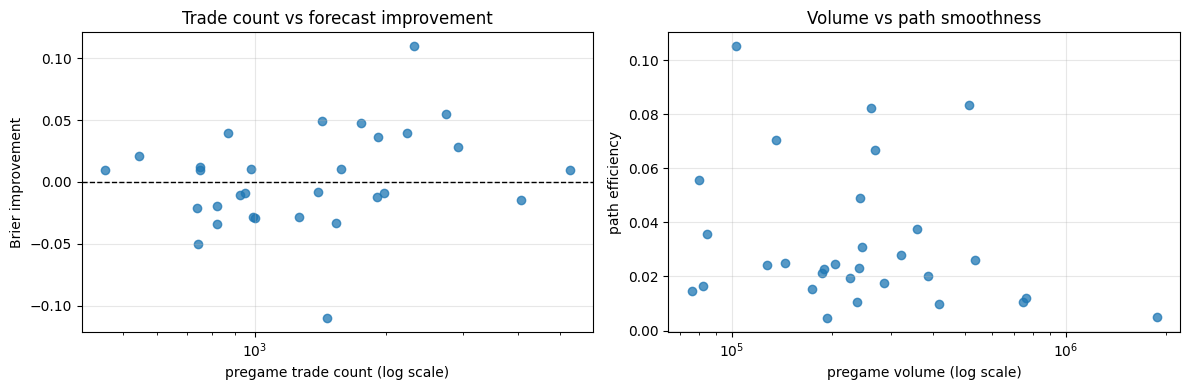

Liquidity/path diagnostic panel


,event_ticker,market_ticker,team_code,winner_team_code,pregame_trade_count,pregame_volume,brier_improvement,winner_prob_change,path_efficiency,volume_fp,liquidity_dollars,orderbook_total_depth_contracts
0,KXMLBGAME-26MAY201940MILCHC,KXMLBGAME-26MAY201940MILCHC-MIL,MIL,MIL,2311,513883.25,0.1100,0.10,0.083333,1165917.55,0.0,2430619.37
1,KXMLBGAME-26MAY202040LADSD,KXMLBGAME-26MAY202040LADSD-LAD,LAD,LAD,2733,321528.99,0.0553,0.07,0.027888,1385972.98,0.0,4819309.60
2,KXMLBGAME-26MAY201840CLEDET,KXMLBGAME-26MAY201840CLEDET-CLE,CLE,CLE,1426,204520.00,0.0495,0.05,0.024631,3728565.63,0.0,752973.38
3,KXMLBGAME-26MAY201305CINPHI,KXMLBGAME-26MAY201305CINPHI-CIN,CIN,CIN,1748,359644.53,0.0480,0.04,0.037736,2216165.51,0.0,0.00
4,KXMLBGAME-26MAY201840CLEDET,KXMLBGAME-26MAY201840CLEDET-DET,DET,CLE,869,189330.57,0.0400,0.04,0.022727,2060495.27,0.0,759956.31
5,KXMLBGAME-26MAY202040LADSD,KXMLBGAME-26MAY202040LADSD-SD,SD,LAD,2235,245781.06,0.0395,0.05,0.031056,1930006.76,0.0,4780491.65
6,KXMLBGAME-26MAY201305CINPHI,KXMLBGAME-26MAY201305CINPHI-PHI,PHI,CIN,1916,386593.05,0.0363,0.03,0.020134,1714096.77,0.0,0.00
7,KXMLBGAME-26MAY202138ATHLAA,KXMLBGAME-26MAY202138ATHLAA-ATH,ATH,ATH,2925,759611.84,0.0279,0.03,0.012146,5796945.79,0.0,3638659.91
8,KXMLBGAME-26MAY201945PITSTL,KXMLBGAME-26MAY201945PITSTL-PIT,PIT,PIT,543,84161.04,0.0208,0.02,0.035714,502690.19,0.0,1956335.29
9,KXMLBGAME-26MAY201905TORNYY,KXMLBGAME-26MAY201905TORNYY-TOR,TOR,TOR,750,82214.93,0.0123,0.01,0.016393,2215059.36,0.0,307461.72


In [9]:
# Answer 4: do liquidity, trade count, volume, or order book depth correlate
# with smoother or more accurate pregame price discovery?
def orderbook_depth_summary(orderbook_value) -> pd.Series:
    if orderbook_value is None:
        return pd.Series(
            {
                'orderbook_yes_depth_contracts': np.nan,
                'orderbook_no_depth_contracts': np.nan,
                'orderbook_total_depth_contracts': np.nan,
                'best_yes_bid': np.nan,
                'best_no_bid': np.nan,
            }
        )
    if isinstance(orderbook_value, str):
        orderbook = json.loads(orderbook_value)
    elif isinstance(orderbook_value, dict):
        orderbook = orderbook_value
    else:
        return pd.Series(
            {
                'orderbook_yes_depth_contracts': np.nan,
                'orderbook_no_depth_contracts': np.nan,
                'orderbook_total_depth_contracts': np.nan,
                'best_yes_bid': np.nan,
                'best_no_bid': np.nan,
            }
        )

    yes_levels = orderbook.get('yes_dollars') or []
    no_levels = orderbook.get('no_dollars') or []
    yes_depth = sum(float(level[1]) for level in yes_levels if len(level) > 1)
    no_depth = sum(float(level[1]) for level in no_levels if len(level) > 1)
    best_yes_bid = max((float(level[0]) for level in yes_levels), default=np.nan)
    best_no_bid = max((float(level[0]) for level in no_levels), default=np.nan)
    return pd.Series(
        {
            'orderbook_yes_depth_contracts': yes_depth,
            'orderbook_no_depth_contracts': no_depth,
            'orderbook_total_depth_contracts': yes_depth + no_depth,
            'best_yes_bid': best_yes_bid,
            'best_no_bid': best_no_bid,
        }
    )


kxmlbgame_orderbook_context = all_orderbooks_df.loc[
    all_orderbooks_df['market_ticker'].isin(kxmlbgame_markets['market_ticker'])
].drop_duplicates('market_ticker').copy()
orderbook_depth = kxmlbgame_orderbook_context['orderbook'].apply(orderbook_depth_summary)
kxmlbgame_orderbook_context = pd.concat(
    [kxmlbgame_orderbook_context[['market_ticker']], orderbook_depth],
    axis=1,
)

liquidity_analysis = pregame_market_summary.merge(
    kxmlbgame_orderbook_context,
    on='market_ticker',
    how='left',
)

metric_cols = [
    'brier_improvement',
    'winner_prob_change',
    'path_efficiency',
    'winner_prob_slope_per_hour',
]
feature_cols = [
    'pregame_trade_count',
    'pregame_volume',
    'volume_fp',
    'liquidity_dollars',
    'yes_bid_size_fp',
    'yes_ask_size_fp',
    'orderbook_yes_depth_contracts',
    'orderbook_no_depth_contracts',
    'orderbook_total_depth_contracts',
]

correlation_rows = []
for metric in metric_cols:
    for feature in feature_cols:
        if metric not in liquidity_analysis.columns or feature not in liquidity_analysis.columns:
            continue
        valid = liquidity_analysis[[metric, feature]].replace([np.inf, -np.inf], np.nan).dropna()
        if len(valid) < 3 or valid[feature].nunique() < 2 or valid[metric].nunique() < 2:
            spearman_corr = np.nan
        else:
            ranked = valid.rank(method='average')
            spearman_corr = ranked[feature].corr(ranked[metric])
        correlation_rows.append(
            {
                'metric': metric,
                'feature': feature,
                'spearman_corr': spearman_corr,
                'n_markets': len(valid),
            }
        )

pregame_liquidity_correlations = pd.DataFrame(correlation_rows)

print(
    'Spearman correlations are directional diagnostics, not causal claims. '
    'The orderbook fields are scrape-time snapshots, not historical pregame depth.'
)
display(
    pregame_liquidity_correlations
    .sort_values(['metric', 'spearman_corr'], ascending=[True, False])
    .reset_index(drop=True)
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(
    liquidity_analysis['pregame_trade_count'],
    liquidity_analysis['brier_improvement'],
    alpha=0.75,
)
axes[0].axhline(0, color='black', linewidth=1, linestyle='--')
axes[0].set_xscale('log')
axes[0].set_xlabel('pregame trade count (log scale)')
axes[0].set_ylabel('Brier improvement')
axes[0].set_title('Trade count vs forecast improvement')

axes[1].scatter(
    liquidity_analysis['pregame_volume'],
    liquidity_analysis['path_efficiency'],
    alpha=0.75,
)
axes[1].set_xscale('log')
axes[1].set_xlabel('pregame volume (log scale)')
axes[1].set_ylabel('path efficiency')
axes[1].set_title('Volume vs path smoothness')

plt.tight_layout()
plt.show()

liquidity_display_cols = [
    'event_ticker',
    'market_ticker',
    'team_code',
    'winner_team_code',
    'pregame_trade_count',
    'pregame_volume',
    'brier_improvement',
    'winner_prob_change',
    'path_efficiency',
    'volume_fp',
    'liquidity_dollars',
    'orderbook_total_depth_contracts',
]
print('Liquidity/path diagnostic panel')
display(
    liquidity_analysis[[c for c in liquidity_display_cols if c in liquidity_analysis.columns]]
    .sort_values('brier_improvement', ascending=False)
    .reset_index(drop=True)
)


### Paired-market complement diagnostics

Each `KXMLBGAME` event has two complementary team contracts. The winner team's YES price and `1 - loser_team_yes_price` should describe the same underlying probability. In practice, the 0/1/2 improving-contract table above shows that the paired markets do not move perfectly synchronously in the observed trade prints. That can happen because each side trades at different timestamps, trades execute through bid/ask spread, and the two YES prices do not always sum to exactly `1.00` at every observation.

Because we only have trade prints, not a continuous quote stream, the lag analysis below forward-fills one-minute trade prices and looks for lead/lag behavior in minute-to-minute changes.


C:\Users\gabri\AppData\Local\Temp\ipykernel_57024\16734773.py:54: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  pair_path = pd.concat([winner_path, loser_implied_winner_path], axis=1).dropna()
C:\Users\gabri\AppData\Local\Temp\ipykernel_57024\16734773.py:54: Pandas4Warning: Sorting by default when concatenating all DatetimeIndex is deprecated.  In the future, pandas will respect the default of `sort=False`. Specify `sort=True` or `sort=False` to silence this message. If you see this warnings when not directly calling concat, report a bug to pandas.
  pair_path = pd.concat([winner_path, loser_implied_winner_path], axis=1).dropna()
C:\Users\gabri\AppData\Local\Temp\ipykernel_57024\16734773.py:54: Pandas4Warning: Sorting by default when conc

Positive best_delta_lag_minutes means the loser-side implied winner probability best matches the winner-side price after that many minutes. Negative means the loser-side implied probability leads.


,event_ticker,winner_team_code,winner_market_ticker,loser_market_ticker,overlap_minutes,contemporaneous_level_corr,contemporaneous_delta_corr,best_delta_lag_minutes,best_delta_corr,mean_abs_complement_gap,max_abs_complement_gap,median_minutes_winner_trade_to_loser_trade,median_minutes_loser_trade_to_winner_trade,share_winner_trades_followed_by_loser_within_1m,share_loser_trades_followed_by_winner_within_1m
0,KXMLBGAME-26MAY201940MILCHC,MIL,KXMLBGAME-26MAY201940MILCHC-MIL,KXMLBGAME-26MAY201940MILCHC-CHC,4226,0.374757,-0.032621,-7,0.350978,0.025258,0.11,0.000362,0.000173,0.997403,1.0
1,KXMLBGAME-26MAY202138ATHLAA,ATH,KXMLBGAME-26MAY202138ATHLAA-ATH,KXMLBGAME-26MAY202138ATHLAA-LAA,4282,0.444816,0.592305,0,0.592305,0.024021,0.17,0.000769,0.000200,1.000000,1.0
2,KXMLBGAME-26MAY201840CLEDET,CLE,KXMLBGAME-26MAY201840CLEDET-CLE,KXMLBGAME-26MAY201840CLEDET-DET,1708,0.803067,0.042439,-3,0.073849,0.016212,0.08,0.000465,0.000256,1.000000,1.0
3,KXMLBGAME-26MAY201840ATLMIA,ATL,KXMLBGAME-26MAY201840ATLMIA-ATL,KXMLBGAME-26MAY201840ATLMIA-MIA,1695,0.761958,0.012807,10,0.079514,0.014431,0.03,0.000507,0.000097,1.000000,1.0
4,KXMLBGAME-26MAY201305CINPHI,CIN,KXMLBGAME-26MAY201305CINPHI-CIN,KXMLBGAME-26MAY201305CINPHI-PHI,1396,0.602860,-0.000035,7,0.082650,0.013725,0.04,0.000167,0.000183,1.000000,1.0
5,KXMLBGAME-26MAY201340HOUMIN,MIN,KXMLBGAME-26MAY201340HOUMIN-MIN,KXMLBGAME-26MAY201340HOUMIN-HOU,1417,0.725653,-0.000325,-1,0.037981,0.011256,0.02,0.000507,0.000280,1.000000,1.0
6,KXMLBGAME-26MAY201310BALTB,TB,KXMLBGAME-26MAY201310BALTB-TB,KXMLBGAME-26MAY201310BALTB-BAL,1361,0.889533,-0.030406,-6,0.076861,0.010948,0.03,0.000375,0.000049,1.000000,1.0
7,KXMLBGAME-26MAY201905TORNYY,TOR,KXMLBGAME-26MAY201905TORNYY-TOR,KXMLBGAME-26MAY201905TORNYY-NYY,1771,0.636981,0.000013,-7,0.051960,0.009774,0.02,0.000247,0.000794,1.000000,1.0
8,KXMLBGAME-26MAY201540SFAZ,AZ,KXMLBGAME-26MAY201540SFAZ-AZ,KXMLBGAME-26MAY201540SFAZ-SF,1450,0.851187,0.050054,1,0.100317,0.009434,0.02,0.000467,0.000238,1.000000,1.0
9,KXMLBGAME-26MAY201610CWSSEA,SEA,KXMLBGAME-26MAY201610CWSSEA-SEA,KXMLBGAME-26MAY201610CWSSEA-CWS,1580,0.169420,-0.039962,-2,0.079849,0.009386,0.02,0.000353,0.000205,1.000000,1.0


Best minute-change lag distribution


,best_delta_lag_minutes,games
0,-10,1
1,-7,2
2,-6,1
3,-3,1
4,-2,2
5,-1,2
6,0,1
7,1,1
8,3,1
9,7,1


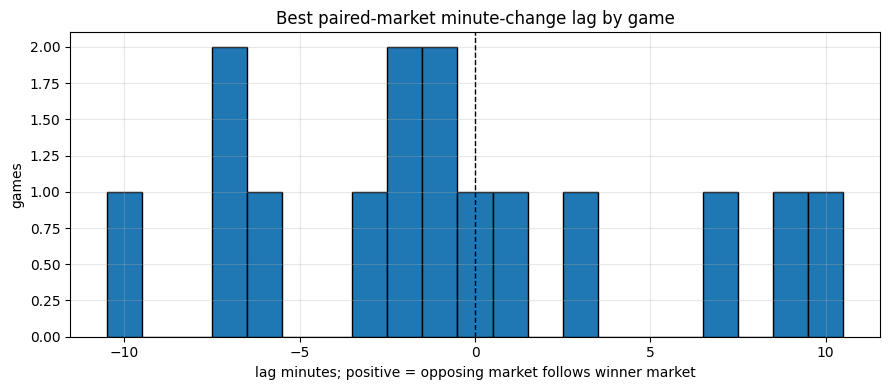

In [10]:
# Do paired KXMLBGAME contracts move together, and does one side lag the other?
LAG_WINDOW_MINUTES = range(-10, 11)


def one_minute_trade_price_path(group: pd.DataFrame) -> pd.Series:
    series = (
        group.sort_values('trade_time_et')
        .set_index('trade_time_et')['yes_price_dollars']
    )
    series = series[~series.index.duplicated(keep='last')]
    return series.resample('1min').last().ffill()


def pearson_corr(left: pd.Series, right: pd.Series) -> float:
    valid = pd.concat([left, right], axis=1).dropna()
    if len(valid) < 3 or valid.iloc[:, 0].nunique() < 2 or valid.iloc[:, 1].nunique() < 2:
        return np.nan
    return valid.iloc[:, 0].corr(valid.iloc[:, 1])


def next_trade_lag_minutes(source_times: pd.Series, target_times: pd.Series) -> np.ndarray:
    source = pd.Series(source_times).dropna().sort_values()
    target = pd.Series(target_times).dropna().sort_values()
    if source.empty or target.empty:
        return np.array([], dtype='float64')

    source_ns = source.astype('int64').to_numpy()
    target_ns = target.astype('int64').to_numpy()
    next_indexes = np.searchsorted(target_ns, source_ns, side='right')
    valid = next_indexes < len(target_ns)
    return (target_ns[next_indexes[valid]] - source_ns[valid]) / 1e9 / 60


pair_rows = []
lag_detail_rows = []
for event_ticker, event_markets in kxmlbgame_markets.groupby('event_ticker'):
    winner_team_code = event_markets['winner_team_code'].dropna().iloc[0]
    winner_market = event_markets.loc[event_markets['team_code'].eq(winner_team_code)]
    loser_market = event_markets.loc[~event_markets['team_code'].eq(winner_team_code)]
    if winner_market.empty or loser_market.empty:
        continue

    winner_market_ticker = winner_market['market_ticker'].iloc[0]
    loser_market_ticker = loser_market['market_ticker'].iloc[0]
    winner_group = pregame_trades.loc[pregame_trades['market_ticker'].eq(winner_market_ticker)]
    loser_group = pregame_trades.loc[pregame_trades['market_ticker'].eq(loser_market_ticker)]
    if winner_group.empty or loser_group.empty:
        continue

    winner_path = one_minute_trade_price_path(winner_group).rename('winner_yes_price')
    loser_implied_winner_path = (1 - one_minute_trade_price_path(loser_group)).rename(
        'loser_implied_winner_price'
    )
    pair_path = pd.concat([winner_path, loser_implied_winner_path], axis=1).dropna()
    if pair_path.empty:
        continue

    pair_delta = pair_path.diff().dropna()
    contemporaneous_level_corr = pearson_corr(
        pair_path['winner_yes_price'],
        pair_path['loser_implied_winner_price'],
    )
    contemporaneous_delta_corr = pearson_corr(
        pair_delta['winner_yes_price'],
        pair_delta['loser_implied_winner_price'],
    )

    lag_corrs = []
    for lag_minutes in LAG_WINDOW_MINUTES:
        shifted_opponent_delta = pair_delta['loser_implied_winner_price'].shift(-lag_minutes)
        corr = pearson_corr(pair_delta['winner_yes_price'], shifted_opponent_delta)
        lag_corrs.append((lag_minutes, corr))
        lag_detail_rows.append(
            {
                'event_ticker': event_ticker,
                'winner_team_code': winner_team_code,
                'lag_minutes': lag_minutes,
                'delta_corr': corr,
            }
        )

    valid_lag_corrs = [(lag, corr) for lag, corr in lag_corrs if pd.notna(corr)]
    if valid_lag_corrs:
        best_lag_minutes, best_delta_corr = max(valid_lag_corrs, key=lambda item: item[1])
    else:
        best_lag_minutes, best_delta_corr = np.nan, np.nan

    winner_to_loser_lags = next_trade_lag_minutes(
        winner_group['trade_time_et'],
        loser_group['trade_time_et'],
    )
    loser_to_winner_lags = next_trade_lag_minutes(
        loser_group['trade_time_et'],
        winner_group['trade_time_et'],
    )

    pair_gap = pair_path['winner_yes_price'] - pair_path['loser_implied_winner_price']
    pair_rows.append(
        {
            'event_ticker': event_ticker,
            'winner_team_code': winner_team_code,
            'winner_market_ticker': winner_market_ticker,
            'loser_market_ticker': loser_market_ticker,
            'overlap_minutes': len(pair_path),
            'contemporaneous_level_corr': contemporaneous_level_corr,
            'contemporaneous_delta_corr': contemporaneous_delta_corr,
            'best_delta_lag_minutes': best_lag_minutes,
            'best_delta_corr': best_delta_corr,
            'mean_abs_complement_gap': pair_gap.abs().mean(),
            'max_abs_complement_gap': pair_gap.abs().max(),
            'median_minutes_winner_trade_to_loser_trade': (
                np.median(winner_to_loser_lags) if len(winner_to_loser_lags) else np.nan
            ),
            'median_minutes_loser_trade_to_winner_trade': (
                np.median(loser_to_winner_lags) if len(loser_to_winner_lags) else np.nan
            ),
            'share_winner_trades_followed_by_loser_within_1m': (
                np.mean(winner_to_loser_lags <= 1) if len(winner_to_loser_lags) else np.nan
            ),
            'share_loser_trades_followed_by_winner_within_1m': (
                np.mean(loser_to_winner_lags <= 1) if len(loser_to_winner_lags) else np.nan
            ),
        }
    )

paired_market_lag_summary = pd.DataFrame(pair_rows)
paired_market_lag_detail = pd.DataFrame(lag_detail_rows)

print(
    'Positive best_delta_lag_minutes means the loser-side implied winner probability '
    'best matches the winner-side price after that many minutes. Negative means the '
    'loser-side implied probability leads.'
)
display(
    paired_market_lag_summary
    .sort_values('mean_abs_complement_gap', ascending=False)
    .reset_index(drop=True)
)

lag_counts = (
    paired_market_lag_summary['best_delta_lag_minutes']
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis('best_delta_lag_minutes')
    .reset_index(name='games')
)
print('Best minute-change lag distribution')
display(lag_counts)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(
    paired_market_lag_summary['best_delta_lag_minutes'].dropna(),
    bins=np.arange(-10.5, 11.5, 1),
    edgecolor='black',
)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_title('Best paired-market minute-change lag by game')
ax.set_xlabel('lag minutes; positive = opposing market follows winner market')
ax.set_ylabel('games')
plt.tight_layout()
plt.show()


#### Interpreting the Lag Distribution

The `best_delta_lag_minutes` table should **not** be read as direct evidence of two-minute-plus arbitrage opportunities. It is a diagnostic based on executed trade prints, not a quote stream.

A positive or negative best lag means that, after forward-filling one-minute trade prices, one side's minute-to-minute trade-price changes correlate best with the other side at that offset. But trade prints are sparse and asynchronous:

- one contract can trade while the complementary contract has no execution,
- a quote can update without a trade and remain invisible here,
- trades execute through bid/ask spread rather than at one canonical fair price,
- the best lag can land at the edge of the tested window when correlations are weak or noisy.

So a `best_delta_lag_minutes` value greater than `2` is better interpreted as: **the trade-print series are not synchronized enough to infer quote leadership reliably.** It may point to a place worth investigating, but it does not prove a stale quote or an executable arbitrage.

To evaluate true arbitrage or stale-market behavior, we would need quote/orderbook data: best bid/ask, size, and timestamped orderbook updates for both complementary contracts. That is why issue #83 tracks whether Kalshi WebSocket `ticker` or `orderbook_delta` capture would add value.


## Live

For live trading, the question shifts from pregame price discovery to in-game repricing. Brier score is intentionally **not** the primary live metric here: once the game is underway, the market should naturally converge toward the eventual winner as game-state information is revealed. Without an independent in-game win-probability model, live Brier mostly measures hindsight convergence rather than market quality.

The live section therefore focuses on path behavior: how much the market reprices toward the eventual winner, whether that movement is smooth or jumpy, and whether liquidity/path diagnostics help explain the shape of that repricing.

The live analysis below collapses the two complementary `KXMLBGAME` contracts into one game-level winner-normalized probability path:

```text
winner_probability = mean(winner_team_yes_price, 1 - loser_team_yes_price)
```

Path-shape metrics used below:

- `live_repricing_to_winner`: last observed live `winner_probability` minus first-pitch `winner_probability`.
- `total_abs_live_move`: sum of absolute one-minute changes in `winner_probability`.
- `path_efficiency`: `abs(live_repricing_to_winner) / total_abs_live_move`. A value near `1.0` means most movement was directional; a value near `0.0` means the market moved around a lot without much net progress.
- `max_1m_abs_move`: largest absolute one-minute change.
- `largest_jump_share_of_path`: `max_1m_abs_move / total_abs_live_move`, or how much of the path was explained by the single largest jump.

This avoids treating paired team contracts as independent signals. Because the May 20, 2026 data is incomplete after the collection outage, the section explicitly reports live coverage and only treats games with enough observed live minutes as analyzable.


In [11]:
# Build one live winner-normalized probability path per game.
MIN_LIVE_MINUTES_FOR_ANALYSIS = 15
LIVE_JUMP_THRESHOLD = 0.05

live_trades = kxmlbgame_trades.loc[
    kxmlbgame_trades['window'].eq('live')
].copy()
live_trades['winner_probability'] = np.where(
    live_trades['actual_outcome'].eq(1.0),
    live_trades['yes_price_dollars'],
    1.0 - live_trades['yes_price_dollars'],
)
def one_minute_price_path(group: pd.DataFrame, price_column: str = 'yes_price_dollars') -> pd.Series:
    series = (
        group.sort_values('trade_time_et')
        .set_index('trade_time_et')[price_column]
    )
    series = series[~series.index.duplicated(keep='last')]
    return series.resample('1min').last().ffill()


def winner_normalized_event_path(event_ticker: str) -> pd.Series:
    event_markets = kxmlbgame_markets.loc[kxmlbgame_markets['event_ticker'].eq(event_ticker)]
    if event_markets.empty:
        return pd.Series(dtype='float64')

    winner_team_code = event_markets['winner_team_code'].dropna().iloc[0]
    game_start_et = event_markets['game_start_et'].iloc[0]
    winner_market = event_markets.loc[event_markets['team_code'].eq(winner_team_code)]
    loser_market = event_markets.loc[~event_markets['team_code'].eq(winner_team_code)]
    if winner_market.empty or loser_market.empty:
        return pd.Series(dtype='float64')

    winner_market_ticker = winner_market['market_ticker'].iloc[0]
    loser_market_ticker = loser_market['market_ticker'].iloc[0]
    event_trades = kxmlbgame_trades.loc[kxmlbgame_trades['event_ticker'].eq(event_ticker)].copy()
    event_live_trades = event_trades.loc[event_trades['trade_time_et'].ge(game_start_et)]
    if event_live_trades.empty:
        return pd.Series(dtype='float64')

    last_live_trade_et = event_live_trades['trade_time_et'].max()
    minute_index = pd.date_range(
        game_start_et.floor('min'),
        last_live_trade_et.ceil('min'),
        freq='1min',
    )

    winner_group = event_trades.loc[event_trades['market_ticker'].eq(winner_market_ticker)]
    loser_group = event_trades.loc[event_trades['market_ticker'].eq(loser_market_ticker)]
    winner_path = one_minute_price_path(winner_group).reindex(minute_index).ffill()
    loser_implied_path = (1.0 - one_minute_price_path(loser_group)).reindex(minute_index).ffill()

    path = pd.concat(
        [winner_path.rename('winner_yes'), loser_implied_path.rename('loser_implied_winner')],
        axis=1,
    ).mean(axis=1, skipna=True)
    path.name = event_ticker
    return path.dropna()


def summarize_live_event(event_ticker: str) -> pd.Series:
    event_markets = kxmlbgame_markets.loc[kxmlbgame_markets['event_ticker'].eq(event_ticker)]
    winner_team_code = event_markets['winner_team_code'].dropna().iloc[0]
    game_start_et = event_markets['game_start_et'].iloc[0]
    event_live_trades = live_trades.loc[live_trades['event_ticker'].eq(event_ticker)]
    path = winner_normalized_event_path(event_ticker)

    if path.empty:
        return pd.Series(
            {
                'winner_team_code': winner_team_code,
                'game_start_et': game_start_et,
                'live_trade_count': 0,
                'live_volume': 0.0,
                'live_markets_with_trades': 0,
                'first_live_trade_et': pd.NaT,
                'last_live_trade_et': pd.NaT,
                'live_duration_minutes': 0.0,
                'winner_prob_first_pitch': np.nan,
                'winner_prob_last_observed': np.nan,
                'live_repricing_to_winner': np.nan,
                'total_abs_live_move': np.nan,
                'path_efficiency': np.nan,
                'max_1m_abs_move': np.nan,
                'jump_count_5c': np.nan,
                'jump_count_10c': np.nan,
                'largest_jump_share_of_path': np.nan,
                'trend_slope_per_hour': np.nan,
            }
        )

    first_prob = path.iloc[0]
    last_prob = path.iloc[-1]
    deltas = path.diff().dropna()
    abs_deltas = deltas.abs()
    total_abs_move = abs_deltas.sum()
    elapsed_hours = (path.index[-1] - path.index[0]).total_seconds() / 3600
    if len(path) > 1 and elapsed_hours > 0:
        hours_from_start = (path.index - path.index[0]).total_seconds() / 3600
        trend_slope_per_hour = np.polyfit(hours_from_start, path.values, 1)[0]
    else:
        trend_slope_per_hour = np.nan

    max_1m_abs_move = abs_deltas.max() if not abs_deltas.empty else np.nan

    return pd.Series(
        {
            'winner_team_code': winner_team_code,
            'game_start_et': game_start_et,
            'live_trade_count': len(event_live_trades),
            'live_volume': event_live_trades['count_fp'].sum(),
            'live_markets_with_trades': event_live_trades['market_ticker'].nunique(),
            'first_live_trade_et': event_live_trades['trade_time_et'].min(),
            'last_live_trade_et': event_live_trades['trade_time_et'].max(),
            'live_duration_minutes': (path.index[-1] - path.index[0]).total_seconds() / 60,
            'winner_prob_first_pitch': first_prob,
            'winner_prob_last_observed': last_prob,
            'live_repricing_to_winner': last_prob - first_prob,
            'total_abs_live_move': total_abs_move,
            'path_efficiency': abs(last_prob - first_prob) / total_abs_move if total_abs_move > 0 else np.nan,
            'max_1m_abs_move': max_1m_abs_move,
            'jump_count_5c': int((abs_deltas >= LIVE_JUMP_THRESHOLD).sum()),
            'jump_count_10c': int((abs_deltas >= 0.10).sum()),
            'largest_jump_share_of_path': max_1m_abs_move / total_abs_move if total_abs_move > 0 else np.nan,
            'trend_slope_per_hour': trend_slope_per_hour,
        }
    )


live_game_paths = {
    event_ticker: winner_normalized_event_path(event_ticker)
    for event_ticker in kxmlbgame_markets['event_ticker'].drop_duplicates().sort_values()
}
live_game_summary = pd.DataFrame(
    [
        summarize_live_event(event_ticker).rename(event_ticker)
        for event_ticker in kxmlbgame_markets['event_ticker'].drop_duplicates().sort_values()
    ]
).rename_axis('event_ticker').reset_index()
live_game_summary['has_any_live_trades'] = live_game_summary['live_trade_count'] > 0
live_game_summary['has_enough_live_coverage'] = (
    live_game_summary['live_duration_minutes'] >= MIN_LIVE_MINUTES_FOR_ANALYSIS
)

print(
    f'Live KXMLBGAME coverage: {live_game_summary["has_any_live_trades"].sum()} of '
    f'{len(live_game_summary)} games have any live trades; '
    f'{live_game_summary["has_enough_live_coverage"].sum()} have at least '
    f'{MIN_LIVE_MINUTES_FOR_ANALYSIS} observed live minutes.'
)
display(
    live_game_summary[
        [
            'event_ticker',
            'winner_team_code',
            'live_trade_count',
            'live_markets_with_trades',
            'live_duration_minutes',
            'winner_prob_first_pitch',
            'winner_prob_last_observed',
            'live_repricing_to_winner',
            'path_efficiency',
            'max_1m_abs_move',
            'jump_count_5c',
            'largest_jump_share_of_path',
            'has_enough_live_coverage',
        ]
    ].sort_values('live_duration_minutes', ascending=False).reset_index(drop=True)
)


Live KXMLBGAME coverage: 15 of 15 games have any live trades; 15 have at least 15 observed live minutes.


,event_ticker,winner_team_code,live_trade_count,live_markets_with_trades,live_duration_minutes,winner_prob_first_pitch,winner_prob_last_observed,live_repricing_to_winner,path_efficiency,max_1m_abs_move,jump_count_5c,largest_jump_share_of_path,has_enough_live_coverage
0,KXMLBGAME-26MAY201905TORNYY,TOR,24341,2,302.0,0.385,0.99,0.605,0.191153,0.140,13,0.044234,True
1,KXMLBGAME-26MAY201945PITSTL,PIT,7208,2,194.0,0.485,0.99,0.505,0.204868,0.130,11,0.052738,True
2,KXMLBGAME-26MAY201510TEXCOL,TEX,31477,2,181.0,0.535,0.99,0.455,0.094693,0.215,29,0.044745,True
3,KXMLBGAME-26MAY201305CINPHI,CIN,14520,2,177.0,0.415,0.99,0.575,0.198618,0.215,15,0.074266,True
4,KXMLBGAME-26MAY202138ATHLAA,ATH,41102,2,174.0,0.555,0.99,0.435,0.080184,0.405,31,0.074654,True
5,KXMLBGAME-26MAY201940BOSKC,BOS,12391,2,173.0,0.480,0.99,0.510,0.128463,0.345,21,0.086902,True
6,KXMLBGAME-26MAY202040LADSD,LAD,10489,2,172.0,0.640,0.99,0.350,0.184211,0.115,6,0.060526,True
7,KXMLBGAME-26MAY201840CLEDET,CLE,21867,2,167.0,0.520,0.99,0.470,0.117794,0.215,24,0.053885,True
8,KXMLBGAME-26MAY201610CWSSEA,SEA,24497,2,166.0,0.565,0.99,0.425,0.094131,0.220,28,0.048726,True
9,KXMLBGAME-26MAY201940MILCHC,MIL,6765,2,156.0,0.490,0.99,0.500,0.387597,0.220,4,0.170543,True


Live-game answer summary


,question,count,total,share
0,Games with any live trades,15,15,1.0
1,Games with >= 15 live minutes,15,15,1.0
2,Analyzable games repriced toward eventual winner,15,15,1.0
3,Analyzable games had at least one >= 5c one-mi...,15,15,1.0
4,Analyzable games had at least one >= 10c one-m...,15,15,1.0


Live metric distribution for analyzable games


,count,mean,std,min,25%,50%,75%,max
live_duration_minutes,15.0,173.133333,3.877935e+01,141.000000,153.000000,167.000000,175.500000,302.000000
live_trade_count,15.0,16773.666667,1.008286e+04,6765.000000,9558.000000,12983.000000,23104.000000,41102.000000
winner_prob_first_pitch,15.0,0.516667,6.950505e-02,0.385000,0.482500,0.520000,0.557500,0.640000
winner_prob_last_observed,15.0,0.990000,1.149190e-16,0.990000,0.990000,0.990000,0.990000,0.990000
live_repricing_to_winner,15.0,0.473333,6.950505e-02,0.350000,0.432500,0.470000,0.507500,0.605000
total_abs_live_move,15.0,3.019333,1.320089e+00,1.120000,1.902500,2.895000,3.980000,5.425000
path_efficiency,15.0,0.189299,8.784365e-02,0.080184,0.123129,0.191153,0.215592,0.387597
max_1m_abs_move,15.0,0.242000,9.149161e-02,0.115000,0.215000,0.215000,0.277500,0.425000
jump_count_5c,15.0,14.666667,9.860938e+00,2.000000,6.500000,13.000000,22.500000,31.000000
largest_jump_share_of_path,15.0,0.094852,5.534112e-02,0.044234,0.053312,0.074654,0.116459,0.236607


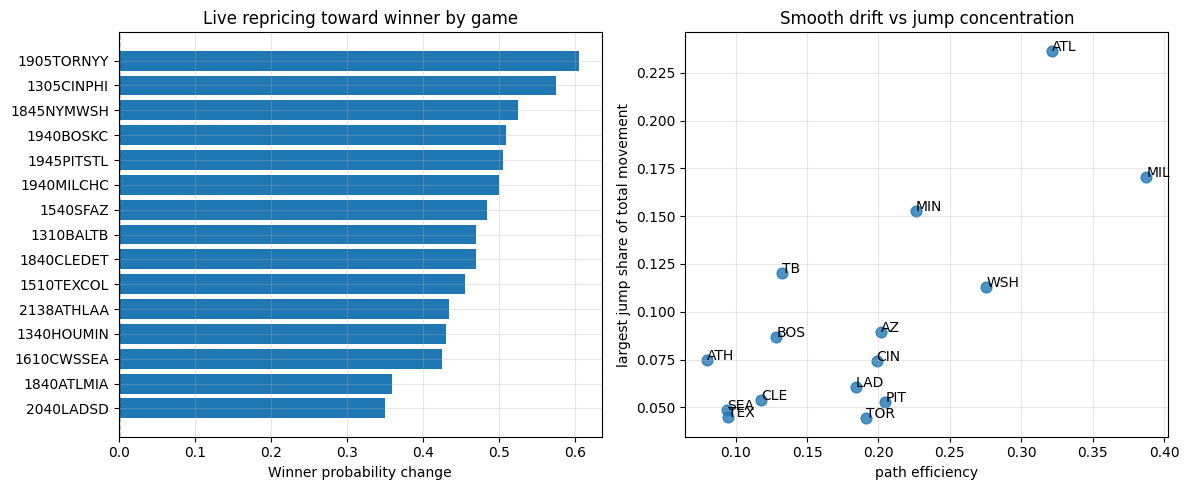

In [12]:
# Answer the live-game questions on games with enough observed live coverage.
analyzable_live_games = live_game_summary.loc[
    live_game_summary['has_enough_live_coverage']
].copy()

live_answer_summary = pd.DataFrame(
    [
        {
            'question': 'Games with any live trades',
            'count': int(live_game_summary['has_any_live_trades'].sum()),
            'total': len(live_game_summary),
            'share': live_game_summary['has_any_live_trades'].mean(),
        },
        {
            'question': f'Games with >= {MIN_LIVE_MINUTES_FOR_ANALYSIS} live minutes',
            'count': len(analyzable_live_games),
            'total': len(live_game_summary),
            'share': len(analyzable_live_games) / len(live_game_summary),
        },
        {
            'question': 'Analyzable games repriced toward eventual winner',
            'count': int((analyzable_live_games['live_repricing_to_winner'] > 0).sum()),
            'total': len(analyzable_live_games),
            'share': (analyzable_live_games['live_repricing_to_winner'] > 0).mean(),
        },
        {
            'question': 'Analyzable games had at least one >= 5c one-minute jump',
            'count': int((analyzable_live_games['jump_count_5c'] > 0).sum()),
            'total': len(analyzable_live_games),
            'share': (analyzable_live_games['jump_count_5c'] > 0).mean(),
        },
        {
            'question': 'Analyzable games had at least one >= 10c one-minute jump',
            'count': int((analyzable_live_games['jump_count_10c'] > 0).sum()),
            'total': len(analyzable_live_games),
            'share': (analyzable_live_games['jump_count_10c'] > 0).mean(),
        },
    ]
)

print('Live-game answer summary')
display(live_answer_summary)

live_distribution_summary = analyzable_live_games[
    [
        'live_duration_minutes',
        'live_trade_count',
        'winner_prob_first_pitch',
        'winner_prob_last_observed',
        'live_repricing_to_winner',
        'total_abs_live_move',
        'path_efficiency',
        'max_1m_abs_move',
        'jump_count_5c',
        'largest_jump_share_of_path',
    ]
].describe(percentiles=[0.25, 0.5, 0.75]).T

print('Live metric distribution for analyzable games')
display(live_distribution_summary)

plot_live_games = analyzable_live_games.copy()
plot_live_games['game_label'] = plot_live_games['event_ticker'].str.replace(
    'KXMLBGAME-26MAY20',
    '',
    regex=False,
)
plot_live_games = plot_live_games.sort_values('live_repricing_to_winner')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].axvline(0, color='black', linewidth=1, linestyle='--')
axes[0].barh(
    plot_live_games['game_label'],
    plot_live_games['live_repricing_to_winner'],
)
axes[0].set_title('Live repricing toward winner by game')
axes[0].set_xlabel('Winner probability change')

axes[1].scatter(
    analyzable_live_games['path_efficiency'],
    analyzable_live_games['largest_jump_share_of_path'],
    s=60,
    alpha=0.8,
)
for _, row in analyzable_live_games.iterrows():
    axes[1].annotate(row['winner_team_code'], (row['path_efficiency'], row['largest_jump_share_of_path']))
axes[1].set_title('Smooth drift vs jump concentration')
axes[1].set_xlabel('path efficiency')
axes[1].set_ylabel('largest jump share of total movement')

plt.tight_layout()
plt.show()


### Interpreting Live Results

For live markets, we do not use Brier score as a headline metric. Once the game starts, the market has direct game-state information and should naturally move toward the eventual winner. Without an independent in-game win-probability model, live Brier mostly tells us that hindsight convergence happened.

Read the live outputs in this order:

1. **Coverage first.** Because the May 20 data is incomplete after the collection outage, games with short or missing live windows should not drive conclusions.
2. **Convergence second.** `live_repricing_to_winner > 0` means the game-level winner probability moved toward the eventual winner between first pitch and the last observed live trade.
3. **Path shape third.** `path_efficiency`, `max_1m_abs_move`, `jump_count_5c`, and `largest_jump_share_of_path` tell us whether that convergence was smooth or concentrated in sudden repricing jumps.

If most analyzable games move toward the winner but also show large one-minute jumps, the right interpretation is not "smooth live drift." It is: **live markets converge toward the final outcome, but much of that convergence appears to come through game-state shocks and abrupt repricing.** Trade prints can show that executed prices moved this way, but an in-game win-probability model would be needed to evaluate whether prices drift relative to expected game state, and quote/orderbook streams would be needed to separate stale quotes from true executable opportunities.


Live winner-probability path by checkpoint


,checkpoint_order,checkpoint,games,mean_winner_probability,median_winner_probability
0,0,first_pitch,15,0.516667,0.520
1,1,15m_live,15,0.526000,0.515
2,2,30m_live,15,0.593333,0.595
3,3,60m_live,15,0.634333,0.630
4,4,120m_live,15,0.628667,0.655
5,5,last_observed,15,0.990000,0.990


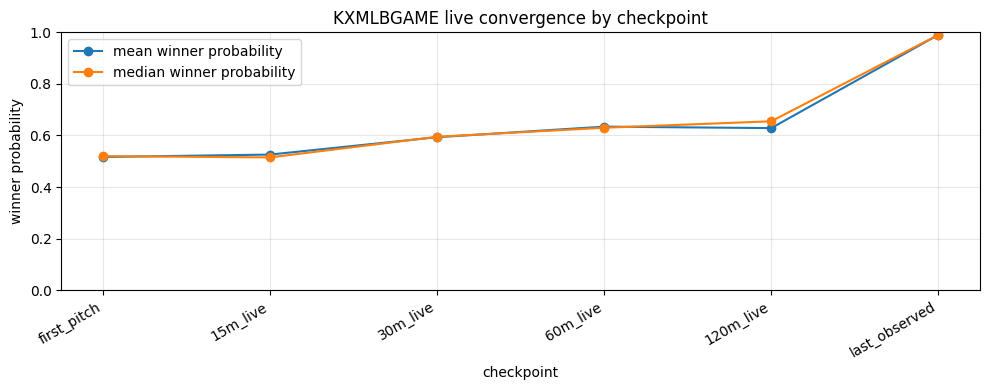

In [13]:
# Live winner-probability path at common elapsed-time checkpoints.
LIVE_CHECKPOINTS = [
    ('first_pitch', pd.Timedelta(minutes=0)),
    ('15m_live', pd.Timedelta(minutes=15)),
    ('30m_live', pd.Timedelta(minutes=30)),
    ('60m_live', pd.Timedelta(minutes=60)),
    ('120m_live', pd.Timedelta(minutes=120)),
    ('last_observed', None),
]

live_checkpoint_rows = []
for _, row in live_game_summary.iterrows():
    event_ticker = row['event_ticker']
    path = live_game_paths.get(event_ticker, pd.Series(dtype='float64'))
    if path.empty:
        continue
    for checkpoint_order, (checkpoint, offset) in enumerate(LIVE_CHECKPOINTS):
        if offset is None:
            selected_time = path.index[-1]
        else:
            selected_time = row['game_start_et'] + offset
            if selected_time > path.index[-1]:
                continue
        eligible = path.loc[path.index <= selected_time]
        if eligible.empty:
            continue
        winner_probability = eligible.iloc[-1]
        live_checkpoint_rows.append(
            {
                'event_ticker': event_ticker,
                'winner_team_code': row['winner_team_code'],
                'checkpoint_order': checkpoint_order,
                'checkpoint': checkpoint,
                'checkpoint_time_et': selected_time,
                'winner_probability': winner_probability,
            }
        )

live_checkpoint_prices = pd.DataFrame(live_checkpoint_rows)
live_checkpoint_summary = live_checkpoint_prices.groupby(
    ['checkpoint_order', 'checkpoint'],
    as_index=False,
).agg(
    games=('event_ticker', 'nunique'),
    mean_winner_probability=('winner_probability', 'mean'),
    median_winner_probability=('winner_probability', 'median'),
)

print('Live winner-probability path by checkpoint')
display(live_checkpoint_summary)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    live_checkpoint_summary['checkpoint'],
    live_checkpoint_summary['mean_winner_probability'],
    marker='o',
    label='mean winner probability',
)
ax.plot(
    live_checkpoint_summary['checkpoint'],
    live_checkpoint_summary['median_winner_probability'],
    marker='o',
    label='median winner probability',
)
ax.set_title('KXMLBGAME live convergence by checkpoint')
ax.set_xlabel('checkpoint')
ax.set_ylabel('winner probability')
ax.set_ylim(0, 1)
ax.legend()
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


Live correlation diagnostics use only games with enough observed live coverage. Treat them as hypothesis generation, not causal estimates.


,metric,feature,spearman_corr,n_games
0,largest_jump_share_of_path,pregame_volume,0.464286,15
1,largest_jump_share_of_path,pregame_trade_count,0.242857,15
2,largest_jump_share_of_path,orderbook_total_depth_contracts,0.075615,15
3,largest_jump_share_of_path,market_volume_fp,-0.364286,15
4,largest_jump_share_of_path,live_volume,-0.507143,15
5,largest_jump_share_of_path,live_trade_count,-0.617857,15
6,largest_jump_share_of_path,market_liquidity_dollars,NaN,15
7,live_repricing_to_winner,live_trade_count,-0.084004,15
8,live_repricing_to_winner,orderbook_total_depth_contracts,-0.095065,15
9,live_repricing_to_winner,live_volume,-0.125112,15


Live liquidity/path rank-correlation matrix


,live_repricing_to_winner,path_efficiency,max_1m_abs_move,largest_jump_share_of_path,live_trade_count,live_volume,pregame_trade_count,pregame_volume,market_volume_fp,orderbook_total_depth_contracts
live_repricing_to_winner,1.000000,0.225201,-0.249108,-0.162645,-0.084004,-0.125112,-0.418231,-0.389634,-0.176944,-0.095065
path_efficiency,0.225201,1.000000,-0.194780,0.617857,-0.875000,-0.764286,0.025000,0.021429,-0.732143,0.029508
max_1m_abs_move,-0.249108,-0.194780,1.000000,0.553679,0.113621,0.133460,0.227243,0.366114,0.265117,-0.067056
largest_jump_share_of_path,-0.162645,0.617857,0.553679,1.000000,-0.617857,-0.507143,0.242857,0.464286,-0.364286,0.075615
live_trade_count,-0.084004,-0.875000,0.113621,-0.617857,1.000000,0.964286,0.092857,0.128571,0.914286,-0.232379
live_volume,-0.125112,-0.764286,0.133460,-0.507143,0.964286,1.000000,0.225000,0.271429,0.960714,-0.237912
pregame_trade_count,-0.418231,0.025000,0.227243,0.242857,0.092857,0.225000,1.000000,0.800000,0.396429,0.116190
pregame_volume,-0.389634,0.021429,0.366114,0.464286,0.128571,0.271429,0.800000,1.000000,0.460714,0.035041
market_volume_fp,-0.176944,-0.732143,0.265117,-0.364286,0.914286,0.960714,0.396429,0.460714,1.000000,-0.189961
orderbook_total_depth_contracts,-0.095065,0.029508,-0.067056,0.075615,-0.232379,-0.237912,0.116190,0.035041,-0.189961,1.000000


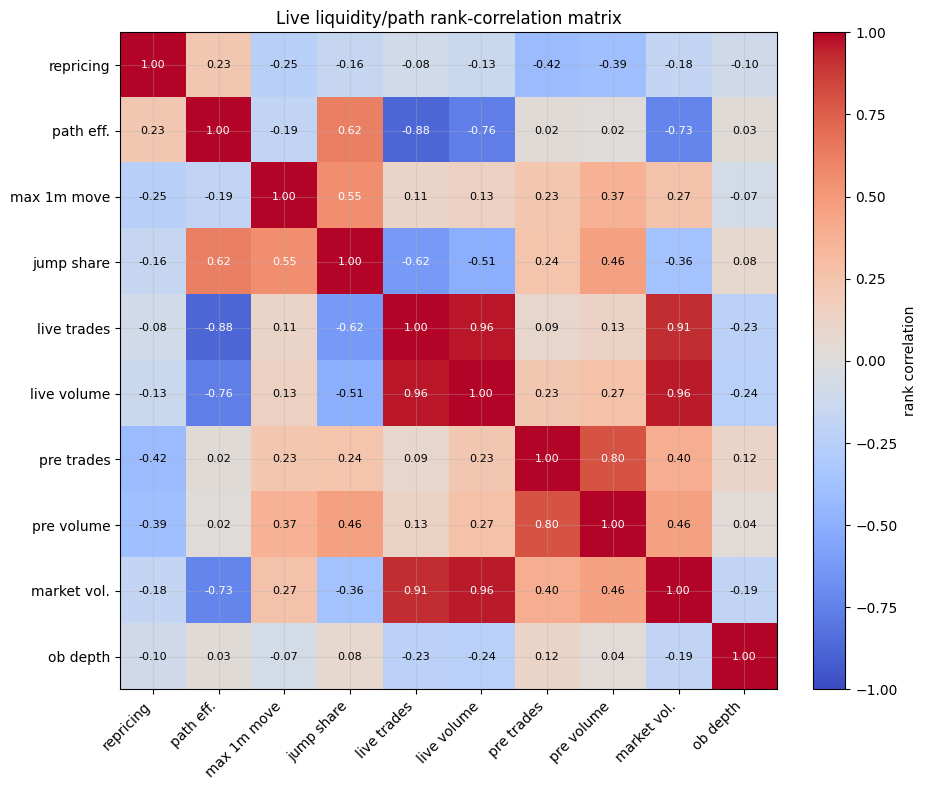

Live liquidity/path diagnostic panel


,event_ticker,winner_team_code,live_duration_minutes,live_trade_count,live_volume,pregame_trade_count,pregame_volume,live_repricing_to_winner,path_efficiency,max_1m_abs_move,jump_count_5c,largest_jump_share_of_path
0,KXMLBGAME-26MAY201905TORNYY,TOR,302.0,24341,5449087.74,2653,318815.25,0.605,0.191153,0.140,13,0.044234
1,KXMLBGAME-26MAY201305CINPHI,CIN,177.0,14520,3182731.69,3664,746237.58,0.575,0.198618,0.215,15,0.074266
2,KXMLBGAME-26MAY201845NYMWSH,WSH,141.0,8889,1759203.98,1663,366154.00,0.525,0.275591,0.215,7,0.112861
3,KXMLBGAME-26MAY201940BOSKC,BOS,173.0,12391,2205317.03,1723,264126.47,0.510,0.128463,0.345,21,0.086902
4,KXMLBGAME-26MAY201945PITSTL,PIT,194.0,7208,1482451.48,2116,310131.23,0.505,0.204868,0.130,11,0.052738
5,KXMLBGAME-26MAY201940MILCHC,MIL,156.0,6765,1487851.98,3774,776065.94,0.500,0.387597,0.220,4,0.170543
6,KXMLBGAME-26MAY201540SFAZ,AZ,146.0,12983,2979466.26,2084,481539.75,0.485,0.201663,0.215,10,0.089397
7,KXMLBGAME-26MAY201310BALTB,TB,154.0,17888,4513159.93,6252,2406806.32,0.470,0.132768,0.425,16,0.120056
8,KXMLBGAME-26MAY201840CLEDET,CLE,167.0,21867,5394446.44,2295,393850.57,0.470,0.117794,0.215,24,0.053885
9,KXMLBGAME-26MAY201510TEXCOL,TEX,181.0,31477,6551892.09,2430,493021.56,0.455,0.094693,0.215,29,0.044745


In [14]:
# Live liquidity/path diagnostics. These are directional diagnostics only;
# scrape-time orderbook fields are not a substitute for live quote history.
live_event_context = pregame_market_summary.groupby('event_ticker', as_index=False).agg(
    pregame_trade_count=('pregame_trade_count', 'sum'),
    pregame_volume=('pregame_volume', 'sum'),
    market_volume_fp=('volume_fp', 'sum'),
    market_liquidity_dollars=('liquidity_dollars', 'sum'),
)

if 'liquidity_analysis' in globals() and 'orderbook_total_depth_contracts' in liquidity_analysis.columns:
    orderbook_event_context = liquidity_analysis.groupby('event_ticker', as_index=False).agg(
        orderbook_total_depth_contracts=('orderbook_total_depth_contracts', 'sum'),
        orderbook_yes_depth_contracts=('orderbook_yes_depth_contracts', 'sum'),
        orderbook_no_depth_contracts=('orderbook_no_depth_contracts', 'sum'),
    )
    live_event_context = live_event_context.merge(orderbook_event_context, on='event_ticker', how='left')

live_liquidity_analysis = analyzable_live_games.merge(
    live_event_context,
    on='event_ticker',
    how='left',
)

live_metric_cols = [
    'live_repricing_to_winner',
    'path_efficiency',
    'max_1m_abs_move',
    'largest_jump_share_of_path',
]
live_feature_cols = [
    'live_trade_count',
    'live_volume',
    'pregame_trade_count',
    'pregame_volume',
    'market_volume_fp',
    'market_liquidity_dollars',
    'orderbook_total_depth_contracts',
]

live_correlation_rows = []
for metric in live_metric_cols:
    for feature in live_feature_cols:
        if metric not in live_liquidity_analysis.columns or feature not in live_liquidity_analysis.columns:
            continue
        valid = live_liquidity_analysis[[metric, feature]].replace([np.inf, -np.inf], np.nan).dropna()
        if len(valid) < 3 or valid[feature].nunique() < 2 or valid[metric].nunique() < 2:
            spearman_corr = np.nan
        else:
            ranked = valid.rank(method='average')
            spearman_corr = ranked[feature].corr(ranked[metric])
        live_correlation_rows.append(
            {
                'metric': metric,
                'feature': feature,
                'spearman_corr': spearman_corr,
                'n_games': len(valid),
            }
        )

live_liquidity_correlations = pd.DataFrame(live_correlation_rows)

print(
    'Live correlation diagnostics use only games with enough observed live coverage. '
    'Treat them as hypothesis generation, not causal estimates.'
)
display(
    live_liquidity_correlations
    .sort_values(['metric', 'spearman_corr'], ascending=[True, False])
    .reset_index(drop=True)
)

live_corr_cols = [
    column
    for column in live_metric_cols + live_feature_cols
    if column in live_liquidity_analysis.columns
]
live_corr_input = live_liquidity_analysis[live_corr_cols].replace([np.inf, -np.inf], np.nan)
live_corr_cols = [
    column
    for column in live_corr_cols
    if live_corr_input[column].dropna().nunique() > 1
    and live_corr_input[column].dropna().size >= 3
]
live_corr_matrix = live_corr_input[live_corr_cols].rank(method='average').corr()

print('Live liquidity/path rank-correlation matrix')
display(live_corr_matrix)

label_map = {
    'live_repricing_to_winner': 'repricing',
    'path_efficiency': 'path eff.',
    'max_1m_abs_move': 'max 1m move',
    'largest_jump_share_of_path': 'jump share',
    'live_trade_count': 'live trades',
    'live_volume': 'live volume',
    'pregame_trade_count': 'pre trades',
    'pregame_volume': 'pre volume',
    'market_volume_fp': 'market vol.',
    'market_liquidity_dollars': 'liquidity',
    'orderbook_total_depth_contracts': 'ob depth',
}
corr_labels = [label_map.get(column, column) for column in live_corr_matrix.columns]

fig, ax = plt.subplots(figsize=(10, 8))
heatmap = ax.imshow(live_corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_title('Live liquidity/path rank-correlation matrix')
ax.set_xticks(range(len(corr_labels)))
ax.set_xticklabels(corr_labels, rotation=45, ha='right')
ax.set_yticks(range(len(corr_labels)))
ax.set_yticklabels(corr_labels)

for row_idx in range(len(live_corr_matrix.index)):
    for col_idx in range(len(live_corr_matrix.columns)):
        value = live_corr_matrix.iloc[row_idx, col_idx]
        if pd.notna(value):
            ax.text(
                col_idx,
                row_idx,
                f'{value:.2f}',
                ha='center',
                va='center',
                color='white' if abs(value) >= 0.55 else 'black',
                fontsize=8,
            )

fig.colorbar(heatmap, ax=ax, fraction=0.046, pad=0.04, label='rank correlation')
plt.tight_layout()
plt.show()

print('Live liquidity/path diagnostic panel')
display(
    live_liquidity_analysis[
        [
            'event_ticker',
            'winner_team_code',
            'live_duration_minutes',
            'live_trade_count',
            'live_volume',
            'pregame_trade_count',
            'pregame_volume',
            'live_repricing_to_winner',
            'path_efficiency',
            'max_1m_abs_move',
            'jump_count_5c',
            'largest_jump_share_of_path',
        ]
    ].sort_values('live_repricing_to_winner', ascending=False).reset_index(drop=True)
)


### Live Takeaways

For this slate, the useful live conclusion is about **path shape**, not whether the market eventually moved toward the winner. Moving toward the winner is expected once the game starts and the market observes game-state information.

Current takeaways:

- Coverage is limited by the May 20 collection outage, so only games with enough observed live minutes should drive interpretation.
- Most analyzable `KXMLBGAME` markets reprice toward the eventual winner from first pitch to the last observed live trade.
- The repricing is not smooth drift. Most analyzable games show at least one `5c` one-minute jump, and many show at least one `10c` one-minute jump.
- Low `path_efficiency` means prices often move around substantially relative to the final net move. That is consistent with choppy, game-state-driven repricing.
- Trade prints show executed repricing, but they do not prove stale quotes, arbitrage, or quote leadership. Quote/orderbook streams are needed for that.

The next analytical step is to layer in pitch-by-pitch or event-level MLB game data. If the largest one-minute jumps line up with run-scoring plays, pitching changes, bases-loaded situations, or late-inning leverage events, then we can separate ordinary live convergence from specific game-state shocks. With an independent in-game win-probability model, we could also test whether Kalshi prices drift relative to expected game state rather than merely drifting toward the known final winner.
